# 1. Entorno experimental y reproducibilidad

## 1.1 Librerías

In [1]:
# =========================================================
# 1. Librerías estándar de Python
# =========================================================
import sys
import os
import time
import random
import shutil
import copy
from collections import Counter

# =========================================================
# 2. Manipulación de datos y matemáticas
# =========================================================
import numpy as np
import pandas as pd

# =========================================================
# 3. Deep Learning: PyTorch y torchvision
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

# =========================================================
# 4. Machine Learning clásico y métricas
# =========================================================
import sklearn
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# 5. Visualización
# =========================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 6. Procesamiento de imágenes y tipografía
# =========================================================
import PIL.Image as Image
import PIL.ImageOps as ImageOps
import PIL.ImageDraw as ImageDraw
import PIL.ImageFont as ImageFont
import matplotlib.font_manager as fm

# =========================================================
# 7. Entorno interactivo / notebooks
# =========================================================
import IPython
from IPython.display import display, Markdown

# =========================================================
# 8. Configuración específica para notebooks
# =========================================================
%matplotlib inline

# =========================================================
# 9. Verificación exhaustiva de versiones
# =========================================================
print("=== Configuración del Entorno ===")
print(f"Python Runtime       : {sys.version.split()[0]}")
print(f"PyTorch Version      : {torch.__version__}")
print(f"Torchvision Version  : {torchvision.__version__}")
print(f"Numpy Version        : {np.__version__}")
print(f"Pandas Version       : {pd.__version__}")
print(f"Matplotlib Version   : {matplotlib.__version__}")
print(f"Seaborn Version      : {sns.__version__}")
print(f"Scikit-learn Version : {sklearn.__version__}")
print(f"IPython Version      : {IPython.__version__}")

=== Configuración del Entorno ===
Python Runtime       : 3.12.10
PyTorch Version      : 2.8.0+cu126
Torchvision Version  : 0.23.0+cu126
Numpy Version        : 2.2.6
Pandas Version       : 2.3.3
Matplotlib Version   : 3.10.8
Seaborn Version      : 0.13.2
Scikit-learn Version : 1.7.2
IPython Version      : 9.9.0


## 1.2 Configuración del dispositivo de cómputo

In [2]:
def setup_environment():
    """
    Configura el dispositivo de cómputo y los parámetros del DataLoader.
    Las decisiones priorizan estabilidad sobre paralelización agresiva en Windows.
    """
    print("\n=== Detección de Hardware ===")
    
    # Información de CPU
    cpu_cores = os.cpu_count()
    if cpu_cores is not None:
        print(f"Núcleos lógicos CPU  : {cpu_cores}")
    
    # Configuración GPU/CPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
        gpu_name = torch.cuda.get_device_name(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"Dispositivo          : GPU ({gpu_name})")
        print(f"VRAM Disponible      : {vram_gb:.2f} GB")
    else:
        device = torch.device("cpu")
        print("Dispositivo          : CPU")

    # Configuración de Workers para DataLoader
    if os.name == 'nt':
        num_workers = 0
        print("Configuración OS     : Windows (num_workers=0)")
    else:
        num_workers = 2
        print("Configuración OS     : Unix/Linux (num_workers=2)")

    return device, num_workers

# Ejecución de la configuración
device, NUM_WORKERS = setup_environment()

print("-" * 60)
print(f"Configuración Lista -> Device: {device} | Workers: {NUM_WORKERS}")


=== Detección de Hardware ===
Núcleos lógicos CPU  : 32
Dispositivo          : GPU (NVIDIA GeForce RTX 4060)
VRAM Disponible      : 8.00 GB
Configuración OS     : Windows (num_workers=0)
------------------------------------------------------------
Configuración Lista -> Device: cuda | Workers: 0


## 1.3. Control de aleatoriedad

In [3]:
def set_seed(seed=42):
    """Fija las semillas para garantizar reproducibilidad en CPU y GPU."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Determinismo en operaciones de convolución
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"\nSemilla global fijada en: {seed}")

# Generador para reproducibilidad en DataLoaders
g_cpu = torch.Generator()
g_cpu.manual_seed(42)

set_seed(42)


Semilla global fijada en: 42


# 2. Análisis previo

## Teoria 
### Estructura jerárquica del sistema de archivos

El conjunto de datos presenta una arquitectura de directorios ampliada que distribuye el volumen masivo de imágenes de entrenamiento en múltiples lotes. La jerarquía organizativa exacta es la siguiente:

* **`chexpertchestxrays-u20210408`**: Directorio raíz principal que engloba la totalidad del conjunto de datos.
    * **Archivos ubicados en el nivel raíz**:
        * **`CHEXPERT DEMO.xlsx`**: Documento tabular que proporciona variables sociodemográficas complementarias de la cohorte poblacional.
        * **`README.md`**: Archivo de texto que contiene la documentación técnica principal y las directrices de uso del conjunto de datos.
        * **`train_cheXbert.csv`**: Matriz de entrenamiento alternativa generada por el modelo automatizado CheXbert.
        * **`train_visualCheXbert.csv`**: Matriz de entrenamiento binaria generada mediante el sistema VisualCheXbert.
    * **`CheXpert-v1.0 batch 1 (validate & csv)`**: Directorio reservado para los conjuntos de validación y metadatos originales.
        * Contiene un subdirectorio anidado homónimo que encapsula físicamente:
            * **`train.csv`**: Matriz original de etiquetas de la partición de entrenamiento (CheXpert labeler).
            * **`valid`**: Directorio que aloja las imágenes radiológicas exclusivas para la validación algorítmica.
            * **`valid.csv`**: Archivo de etiquetas de referencia (ground truth) derivado del consenso médico para el conjunto de validación.
    * **Directorios de partición de entrenamiento**: 
        * **`CheXpert-v1.0 batch 2 (train 1)`**.
        * **`CheXpert-v1.0 batch 3 (train 2)`**.
        * **`CheXpert-v1.0 batch 4 (train 3)`**.
        * Estos tres directorios segmentan el corpus total de imágenes de entrenamiento. Su arquitectura interna mantiene una topología idéntica:
            * **`patientXXXXX`**: Sistema de carpetas segregadas unívocamente por identificador de paciente, diseñado para garantizar la independencia de los datos e impedir la contaminación cruzada durante el desarrollo algorítmico.
                * **`studyX`**: Subcarpetas que representan eventos de adquisición clínica independientes para un mismo paciente.
                    * **`viewX_frontal.jpg` / `viewX_lateral.jpg`**: Archivos de imagen que contienen las radiografías, cuya nomenclatura detalla la secuencia de la vista y la proyección anatómica.

### Distribución lógica y particiones del conjunto de datos

El corpus total abarca 224.316 radiografías de tórax correspondientes a 65.240 pacientes, adquiridas retrospectivamente entre octubre de 2002 y julio de 2017. Las particiones metodológicas se estructuran de la siguiente manera:

* **Conjunto de entrenamiento (Train):** Base de datos masiva cuyas etiquetas han sido generadas automáticamente mediante algoritmos de extracción aplicados sobre los informes radiológicos originales.
* **Conjunto de validación (Valid):** Actúa como estándar de referencia calibrado. Las anotaciones originales de tres radiólogos certificados se sometieron a un proceso de binarización: los diagnósticos confirmados y probables ("present", "uncertain likely") se computaron como positivos, mientras que los diagnósticos ausentes o improbables ("absent", "uncertain unlikely") se catalogaron como negativos. El estándar de referencia final se define mediante el voto mayoritario de estas anotaciones.
* **Conjunto de prueba (Test):** Partición oculta de 500 estudios de pacientes independientes y no observados en fases previas. El estándar de referencia se establece mediante el consenso de cinco especialistas, utilizándose exclusivamente para evaluar el rendimiento algorítmico frente a radiólogos humanos.

### Variables demográficas y técnicas de adquisición

Las matrices de datos estructuran la información de cada radiografía mediante un conjunto uniforme de variables independientes:

* **Path:** Ruta unívoca de acceso al archivo de imagen.
* **Sex / GENDER:** Sexo del paciente.
* **Age / AGE_AT_CXR:** Edad del paciente en el momento de la adquisición.
* **Frontal/Lateral:** Tipo de proyección anatómica general.
* **AP/PA:** Posición específica de adquisición para proyecciones frontales (anteroposterior o posteroanterior).

Adicionalmente, el registro demográfico complementario segmenta a la población incorporando vectores de raza primaria (`PRIMARY_RACE`) y etnicidad (`ETHNICITY`), lo que facilita la evaluación de sesgos algorítmicos en subpoblaciones específicas.

### Taxonomía clínica y sistemas de etiquetado

La extracción de información radiológica evalúa sistemáticamente 14 variables diagnósticas categóricas:

1. No Finding (Ausencia de hallazgos)
2. Enlarged Cardiomediastinum (Ensanchamiento cardiomediastínico)
3. Cardiomegaly (Cardiomegalia)
4. Lung Opacity (Opacidad pulmonar)
5. Lung Lesion (Lesión pulmonar)
6. Edema (Edema)
7. Consolidation (Consolidación)
8. Pneumonia (Neumonía)
9. Atelectasis (Atelectasia)
10. Pneumothorax (Neumotórax)
11. Pleural Effusion (Derrame pleural)
12. Pleural Other (Otras alteraciones pleurales)
13. Fracture (Fractura)
14. Support Devices (Dispositivos de soporte)

Para el modelado de las imágenes de entrenamiento, la arquitectura proporciona tres sistemas de etiquetado automático, cuya codificación difiere según la matriz de datos empleada:

* **Sistemas con modelado de incertidumbre (`train.csv` y `train_cheXbert.csv`):** Emplean un formato de coma flotante para representar diagnósticos positivos (1.0), diagnósticos negativos (0.0), diagnósticos inciertos o ambiguos (-1.0) y omisiones en el informe original (celdas vacías o valores nulos).
    * **CheXpert Labeler (`train.csv`):** Clasifica las observaciones capturando la incertidumbre inherente al informe original.
    * **CheXbert Labeler (`train_cheXbert.csv`):** Emplea la misma taxonomía de clases discretas pero utiliza una arquitectura mejorada. Su uso se recomienda como alternativa preferente sobre el etiquetador original, ya que demuestra superioridad semántica en evaluaciones realizadas sobre informes anotados por radiólogos.
* **Sistemas estrictamente binarios (`train_visualCheXbert.csv` y `valid.csv`):** Restringen el espacio de etiquetas a presencia confirmada (1.0) y ausencia confirmada (0.0). 
    * **VisualCheXbert Labeler (`train_visualCheXbert.csv`):** Genera etiquetas estrictamente binarias. Este modelo optimiza la correspondencia clínica al haber sido validado en pruebas donde los radiólogos etiquetaron directamente la imagen de rayos X asociada al informe. En el conjunto de validación (`valid.csv`), esta binarización resulta del consenso médico formal.

El enfoque matemático para integrar la etiqueta de incertidumbre (-1.0) en las versiones no binarias recae en el diseño del modelo, admitiendo técnicas como su omisión (U-Ignore), asimilación a negativo (U-Zeroes), asimilación a positivo (U-Ones), tratamiento como clase independiente (U-MultiClass) o reetiquetado probabilístico iterativo (U-SelfTrained).

In [4]:
# Ruta del archivo CSV
# ruta = "chexpert_csv/train_cheXbert.csv"

# Cargar el dataset, tratando '?' como valor faltante (NaN) y eliminando espacios iniciales
# df = pd.read_csv(ruta, na_values='?', skipinitialspace=True)
# df = pd.read_csv(ruta)

## 2.1. Lectura del archivo CSV

In [5]:
ruta = "chexpert_csv/train_cheXbert.csv"

# Definición semántica de las columnas
cols_patologias = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion',
    'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax',
    'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'No Finding'
]

# Diccionario de optimización de tipos
tipos_optimizados = {
    'Sex': 'category',
    'Frontal/Lateral': 'category',
    'AP/PA': 'category',
    'Age': 'float32' # Se asigna float32 como medida de seguridad ante posibles NaNs
}

# Asignación de float32 a todas las patologías para reducir huella de memoria
for patologia in cols_patologias:
    tipos_optimizados[patologia] = 'float32'

df_ini = pd.read_csv(ruta, dtype=tipos_optimizados)
df_ini.columns = df_ini.columns.str.strip()

display(Markdown(f"**Número total de observaciones:** {df_ini.shape[0]}"))
display(Markdown(f"**Número de variables (columnas):** {df_ini.shape[1]}"))
display(Markdown("#### Primeras filas del dataset:"))
display(df_ini.head())

**Número total de observaciones:** 223414

**Número de variables (columnas):** 19

#### Primeras filas del dataset:

,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68.0,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,1.0
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87.0,Frontal,AP,NaN,1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83.0,Frontal,AP,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
3,CheXpert-v1.0/train/patient00002/study1/view2_...,Female,83.0,Lateral,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41.0,Frontal,AP,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


## 2.2 Estructura semántica del dataset

In [6]:
# Segmentación basada en el dominio del problema en lugar de dtypes
metadatos_tecnicos = ['Path', 'Frontal/Lateral', 'AP/PA']
variables_demograficas = ['Sex', 'Age']
variables_clinicas = cols_patologias

tabla_vars = f""" 
| Categoría conceptual | Variables incluidas |
|----------------------|---------------------|
| **Metadatos e Identificación** | {', '.join(metadatos_tecnicos)} |
| **Variables Demográficas** | {', '.join(variables_demograficas)} |
| **Variables Clínicas (Objetivo)** | {', '.join(variables_clinicas)} |
"""
display(Markdown(tabla_vars))

 
| Categoría conceptual | Variables incluidas |
|----------------------|---------------------|
| **Metadatos e Identificación** | Path, Frontal/Lateral, AP/PA |
| **Variables Demográficas** | Sex, Age |
| **Variables Clínicas (Objetivo)** | Enlarged Cardiomediastinum, Cardiomegaly, Lung Opacity, Lung Lesion, Edema, Consolidation, Pneumonia, Atelectasis, Pneumothorax, Pleural Effusion, Pleural Other, Fracture, Support Devices, No Finding |


## 2.3 Estadísticas básicas del dataset

In [7]:
# -------------------------------------------------------------------------
# Análisis de variables continuas
# -------------------------------------------------------------------------
display(Markdown("### Análisis descriptivo de variables continuas"))
tabla_estats_edad = df_ini[['Age']].describe().T
display(tabla_estats_edad)

# -------------------------------------------------------------------------
# Análisis de metadatos categóricos
# -------------------------------------------------------------------------
display(Markdown("### Distribución de variables categóricas (Metadatos)"))
variables_cat = ['Sex', 'Frontal/Lateral', 'AP/PA']

for col in variables_cat:
    # dropna=False es vital para auditar la dependencia lógica en 'AP/PA'
    conteo_cat = df_ini[col].value_counts(dropna=False).to_frame(name='Frecuencia')
    conteo_cat['% del total'] = (conteo_cat['Frecuencia'] / len(df_ini) * 100).round(2)
    display(Markdown(f"#### Distribución: {col}"))
    display(conteo_cat)

# -------------------------------------------------------------------------
# Prevalencia diagnóstica detallada
# -------------------------------------------------------------------------
display(Markdown("### Prevalencia patológica multietiqueta (Absoluta y Relativa)"))

total_obs = len(df_ini)
stats_patologias = pd.DataFrame(index=cols_patologias)

# Cálculo de la cobertura general (cuántas veces el radiólogo evalúa la región)
stats_patologias['Menciones (No nulos)'] = df_ini[cols_patologias].count()
stats_patologias['% Cobertura'] = (stats_patologias['Menciones (No nulos)'] / total_obs * 100).round(2).astype(str) + "%"

# Función escalar para mapear prevalencia intra-clase
def formatear_columna(condicion):
    conteo = condicion.sum()
    pct = (conteo / total_obs * 100).round(2)
    return conteo.astype(str) + " (" + pct.astype(str) + "%)"

# Desglose vectorizado del diagnóstico
stats_patologias['Positivos (1.0)'] = formatear_columna(df_ini[cols_patologias] == 1.0)
stats_patologias['Negativos (0.0)'] = formatear_columna(df_ini[cols_patologias] == 0.0)
stats_patologias['Inciertos (-1.0)'] = formatear_columna(df_ini[cols_patologias] == -1.0)
stats_patologias['No Mencionados (NaN)'] = formatear_columna(df_ini[cols_patologias].isna())

# Ordenamiento por relevancia documental (mayor a menor cobertura)
stats_patologias = stats_patologias.sort_values(by='Menciones (No nulos)', ascending=False)
display(stats_patologias)

### Análisis descriptivo de variables continuas

,count,mean,std,min,25%,50%,75%,max
Age,223414.0,60.52766,17.995928,0.0,49.0,62.0,74.0,110.0


### Distribución de variables categóricas (Metadatos)

#### Distribución: Sex

,Frecuencia,% del total
Sex,,
Male,132636,59.37
Female,90777,40.63
Unknown,1,0.00


...

,Frecuencia,% del total
Frontal/Lateral,,
Frontal,191027,85.5
Lateral,32387,14.5


#### Distribución: AP/PA

,Frecuencia,% del total
AP/PA,,
AP,161590,72.33
NaN,32387,14.50
PA,29420,13.17
LL,16,0.01
RL,1,0.00


### Prevalencia patológica multietiqueta (Absoluta y Relativa)

,Menciones (No nulos),% Cobertura,Positivos (1.0),Negativos (0.0),Inciertos (-1.0),No Mencionados (NaN)
Pleural Effusion,133226,59.63%,89314 (39.98%),36278 (16.24%),7634 (3.42%),90188 (40.37%)
Support Devices,117277,52.49%,113135 (50.64%),4087 (1.83%),55 (0.02%),106137 (47.51%)
Lung Opacity,108503,48.57%,103092 (46.14%),5096 (2.28%),315 (0.14%),114911 (51.43%)
Edema,86512,38.72%,53058 (23.75%),21243 (9.51%),12211 (5.47%),136902 (61.28%)
Pneumothorax,78967,35.35%,17869 (8.0%),58663 (26.26%),2435 (1.09%),144447 (64.65%)
Consolidation,71894,32.18%,13682 (6.12%),31523 (14.11%),26689 (11.95%),151520 (67.82%)
Atelectasis,69008,30.89%,33862 (15.16%),730 (0.33%),34416 (15.4%),154406 (69.11%)
Cardiomegaly,50638,22.67%,30566 (13.68%),16155 (7.23%),3917 (1.75%),172776 (77.33%)
Enlarged Cardiomediastinum,45191,20.23%,7611 (3.41%),22527 (10.08%),15053 (6.74%),178223 (79.77%)
Pneumonia,27556,12.33%,4856 (2.17%),3314 (1.48%),19386 (8.68%),195858 (87.67%)


## 2.4 Estadísticas cruzadas y análisis multivariante

In [8]:
# -------------------------------------------------------------------------
# Distribución posicional
# -------------------------------------------------------------------------
display(Markdown("### Distribución de posición condicionada al eje de proyección"))
# Filtrado explícito para evaluar el porcentaje AP/PA exclusivamente en vistas frontales
df_frontal = df_ini[df_ini['Frontal/Lateral'] == 'Frontal']
proy_frontal_cruzada = df_frontal['AP/PA'].value_counts(normalize=True).to_frame(name='% dentro de Frontal') * 100
display(proy_frontal_cruzada.round(2))

# -------------------------------------------------------------------------
# Distribución geométrica estratificada
# -------------------------------------------------------------------------
display(Markdown("### Distribución geométrica estratificada por sexo"))
sexo_proy_cruzada = pd.crosstab(df_ini['Sex'], df_ini['Frontal/Lateral'], normalize='index') * 100
sexo_proy_cruzada.columns = [f"{col} (%)" for col in sexo_proy_cruzada.columns]
display(sexo_proy_cruzada.round(2))

# -------------------------------------------------------------------------
# Análisis demográfico cruzado
# -------------------------------------------------------------------------
display(Markdown("### Análisis demográfico continuo (Edad por Sexo)"))
edad_por_sexo = df_ini.groupby('Sex', observed=True)['Age'].agg(['mean', 'median', 'std', 'count']).round(2)
edad_por_sexo.columns = ['Media (Años)', 'Mediana (Años)', 'Desviación Estándar', 'Volumen']
display(edad_por_sexo)

# -------------------------------------------------------------------------
# Prevalencia patológica condicionada
# -------------------------------------------------------------------------
display(Markdown("### Prevalencia patológica condicionada (Ejemplo: Derrame Pleural)"))
patologia_foco = 'Pleural Effusion'

# Evaluación vectorial mediante máscara booleana para evitar expansión de memoria
mascara_positivos = (df_ini[patologia_foco] == 1.0).astype(int)
prev_por_sexo = mascara_positivos.groupby(df_ini['Sex'], observed=True).mean().to_frame(name=f'% {patologia_foco} sobre total') * 100
display(prev_por_sexo.round(2))

# -------------------------------------------------------------------------
# Matriz de co-ocurrencia clínica
# -------------------------------------------------------------------------
display(Markdown("### Matriz de co-ocurrencia clínica (Absoluta y Relativa)"))

# 1. Binarización aislada del espacio de etiquetas clínicas (1.0 = Positivo, resto = 0)
df_pos = (df_ini[cols_patologias] == 1.0).astype(int)

# 2. Producto escalar matricial para conteo absoluto de intersecciones
matriz_cooc_abs = df_pos.T.dot(df_pos)

# 3. Cálculo de prevalencia cruzada porcentual
total_observaciones = len(df_ini)
matriz_cooc_pct = (matriz_cooc_abs / total_observaciones) * 100

# 4. Fusión de matrices (Absoluta y Porcentual)
matriz_final = matriz_cooc_abs.astype(str) + " (" + matriz_cooc_pct.round(2).astype(str) + "%)"

# Visualización 1: Matriz completa
display(Markdown("#### Matriz Global (14 Patologías)"))
display(matriz_final)

# Visualización 2: Submatriz de competición
display(Markdown("#### Submatriz de competición (Top 5 patologías objetivo)"))
cols_top5 = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
display(matriz_final.loc[cols_top5, cols_top5])

### Distribución de posición condicionada al eje de proyección

,% dentro de Frontal
AP/PA,
AP,84.59
PA,15.40
LL,0.01
RL,0.00


### Distribución geométrica estratificada por sexo

,Frontal (%),Lateral (%)
Sex,,
Female,86.89,13.11
Male,84.56,15.44
Unknown,100.00,0.00


### Análisis demográfico continuo (Edad por Sexo)

...

### Matriz de co-ocurrencia clínica (Absoluta y Relativa)

#### Matriz Global (14 Patologías)

,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
Enlarged Cardiomediastinum,7611 (3.41%),1404 (0.63%),3399 (1.52%),384 (0.17%),1968 (0.88%),380 (0.17%),118 (0.05%),862 (0.39%),110 (0.05%),2954 (1.32%),72 (0.03%),328 (0.15%),3453 (1.55%),22 (0.01%)
Cardiomegaly,1404 (0.63%),30566 (13.68%),13807 (6.18%),681 (0.3%),13166 (5.89%),1537 (0.69%),343 (0.15%),4512 (2.02%),611 (0.27%),13563 (6.07%),419 (0.19%),914 (0.41%),15507 (6.94%),0 (0.0%)
Lung Opacity,3399 (1.52%),13807 (6.18%),103092 (46.14%),2774 (1.24%),27222 (12.18%),4271 (1.91%),3346 (1.5%),13133 (5.88%),8252 (3.69%),53293 (23.85%),1831 (0.82%),3226 (1.44%),59284 (26.54%),19 (0.01%)
Lung Lesion,384 (0.17%),681 (0.3%),2774 (1.24%),9346 (4.18%),748 (0.33%),728 (0.33%),316 (0.14%),991 (0.44%),820 (0.37%),3465 (1.55%),391 (0.18%),325 (0.15%),3048 (1.36%),2 (0.0%)
Edema,1968 (0.88%),13166 (5.89%),27222 (12.18%),748 (0.33%),53058 (23.75%),2997 (1.34%),706 (0.32%),8784 (3.93%),1369 (0.61%),27447 (12.29%),329 (0.15%),997 (0.45%),34188 (15.3%),1 (0.0%)
Consolidation,380 (0.17%),1537 (0.69%),4271 (1.91%),728 (0.33%),2997 (1.34%),13682 (6.12%),1213 (0.54%),1817 (0.81%),670 (0.3%),7360 (3.29%),274 (0.12%),356 (0.16%),7318 (3.28%),1 (0.0%)
Pneumonia,118 (0.05%),343 (0.15%),3346 (1.5%),316 (0.14%),706 (0.32%),1213 (0.54%),4856 (2.17%),368 (0.16%),102 (0.05%),1460 (0.65%),106 (0.05%),105 (0.05%),1230 (0.55%),0 (0.0%)
Atelectasis,862 (0.39%),4512 (2.02%),13133 (5.88%),991 (0.44%),8784 (3.93%),1817 (0.81%),368 (0.16%),33862 (15.16%),2896 (1.3%),17188 (7.69%),396 (0.18%),1316 (0.59%),20245 (9.06%),96 (0.04%)
Pneumothorax,110 (0.05%),611 (0.27%),8252 (3.69%),820 (0.37%),1369 (0.61%),670 (0.3%),102 (0.05%),2896 (1.3%),17869 (8.0%),7028 (3.15%),267 (0.12%),721 (0.32%),10817 (4.84%),0 (0.0%)
Pleural Effusion,2954 (1.32%),13563 (6.07%),53293 (23.85%),3465 (1.55%),27447 (12.29%),7360 (3.29%),1460 (0.65%),17188 (7.69%),7028 (3.15%),89314 (39.98%),1059 (0.47%),2514 (1.13%),54834 (24.54%),7 (0.0%)


#### Submatriz de competición (Top 5 patologías objetivo)

,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
Atelectasis,33862 (15.16%),4512 (2.02%),1817 (0.81%),8784 (3.93%),17188 (7.69%)
Cardiomegaly,4512 (2.02%),30566 (13.68%),1537 (0.69%),13166 (5.89%),13563 (6.07%)
Consolidation,1817 (0.81%),1537 (0.69%),13682 (6.12%),2997 (1.34%),7360 (3.29%)
Edema,8784 (3.93%),13166 (5.89%),2997 (1.34%),53058 (23.75%),27447 (12.29%)
Pleural Effusion,17188 (7.69%),13563 (6.07%),7360 (3.29%),27447 (12.29%),89314 (39.98%)


## 2.5 Análisis Visual


El siguiente histograma permite observar la forma, asimetría y dispersión de la edad de los pacientes en el momento de la adquisición radiológica, siendo la única variable numérica continua del conjunto de datos.


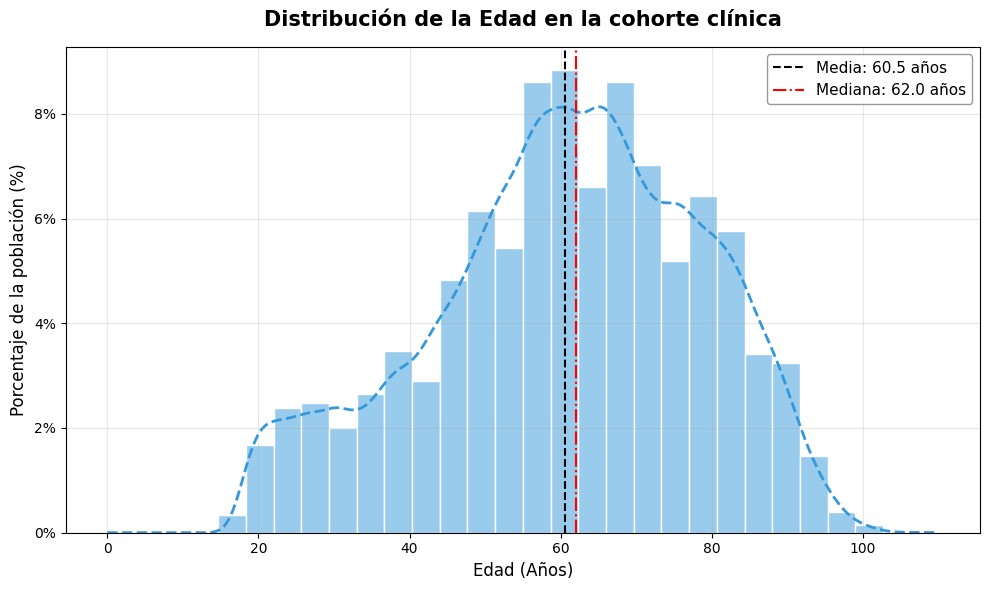

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

display(Markdown("""
El siguiente histograma permite observar la forma, asimetría y dispersión de la edad de los pacientes en el momento de la adquisición radiológica, siendo la única variable numérica continua del conjunto de datos.
"""))

# Configuración del lienzo
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar Histograma con curva de densidad (KDE)
sns.histplot(
    df_ini['Age'].dropna(), 
    bins=30, 
    kde=True, 
    ax=ax, 
    color='#3498db', 
    edgecolor='white',
    stat='percent',
    line_kws={'linewidth': 2, 'linestyle': '--'} # Línea de densidad
)

# Cálculos estadísticos
mean_val = df_ini['Age'].mean()
median_val = df_ini['Age'].median()

# Trazar líneas de tendencia central
ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Media: {mean_val:.1f} años')
ax.axvline(median_val, color='red', linestyle='-.', linewidth=1.5, label=f'Mediana: {median_val:.1f} años')

# Formateo estético del gráfico
ax.set_title("Distribución de la Edad en la cohorte clínica", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Edad (Años)", fontsize=12)
ax.set_ylabel("Porcentaje de la población (%)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.grid(alpha=0.3)
ax.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=11)

# Renderizar
plt.tight_layout()
plt.show()

### 2.5.1. Distribución geométrica de las adquisiciones
Este gráfico de barras expondrá de forma limpia el sesgo de adquisición geométrica (el predominio masivo de proyecciones Frontales y AP).

### 2.5.1. Distribución geométrica de las adquisiciones

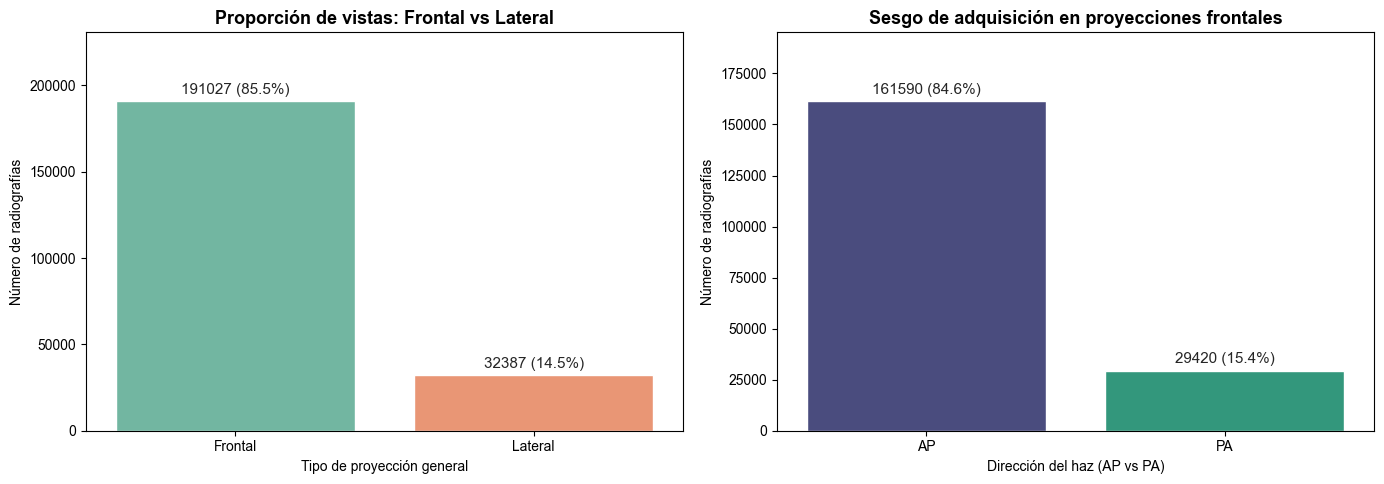

> **Interpretación visual:** Se aprecia un desbalance masivo hacia las proyecciones Anteroposteriores (AP), típicas de pacientes hospitalizados en estado crítico o con movilidad reducida.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("### 2.5.1. Distribución geométrica de las adquisiciones"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------------
# Gráfico 1: Frontal vs Lateral
# -------------------------------------------------------------------
sns.countplot(
    data=df_ini,
    x='Frontal/Lateral', 
    hue='Frontal/Lateral', 
    order=['Frontal', 'Lateral'], 
    palette='Set2', 
    ax=axes[0], 
    legend=False,
    dodge=False
)

axes[0].set_title("Proporción de vistas: Frontal vs Lateral", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Número de radiografías")
axes[0].set_xlabel("Tipo de proyección general")

# Añadir etiquetas de datos absolutos y porcentuales (Gráfico 1)
total_grafico1 = len(df_ini) # Total de observaciones en el dataset
for container in axes[0].containers:
    # Generamos el texto combinando el valor absoluto (v) y calculando su % sobre el total
    etiquetas_g1 = [f"{int(v)} ({v/total_grafico1*100:.1f}%)" if v > 0 else "" for v in container.datavalues]
    axes[0].bar_label(container, labels=etiquetas_g1, padding=3, fontsize=11)

# -------------------------------------------------------------------
# Gráfico 2: AP vs PA (Solo Frontales)
# -------------------------------------------------------------------
# Filtramos explícitamente los errores LL/RL para el gráfico
df_frontal_clean = df_ini[df_ini['AP/PA'].isin(['AP', 'PA'])]

sns.countplot(
    data=df_frontal_clean, 
    x='AP/PA', 
    hue='AP/PA', 
    order=['AP', 'PA'], 
    palette='viridis', 
    ax=axes[1], 
    legend=False, 
    dodge=False
)

axes[1].set_title("Sesgo de adquisición en proyecciones frontales", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Número de radiografías")
axes[1].set_xlabel("Dirección del haz (AP vs PA)")

# Añadir etiquetas de datos absolutos y porcentuales (Gráfico 2)
total_grafico2 = len(df_frontal_clean) # Total de proyecciones exclusivamente frontales
for container in axes[1].containers:
    # Generamos el texto combinando el valor absoluto (v) y calculando su % sobre el total
    etiquetas_g2 = [f"{int(v)} ({v/total_grafico2*100:.1f}%)" if v > 0 else "" for v in container.datavalues]
    axes[1].bar_label(container, labels=etiquetas_g2, padding=3, fontsize=11)

# -------------------------------------------------------------------
# Ajustes estéticos finales
# -------------------------------------------------------------------
# Aumentamos el límite Y superior un 15% (1.15) para que quepan bien las nuevas etiquetas más largas
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.15)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

display(Markdown("> **Interpretación visual:** Se aprecia un desbalance masivo hacia las proyecciones Anteroposteriores (AP), típicas de pacientes hospitalizados en estado crítico o con movilidad reducida."))

### 2.5.2. Desbalance de clases en patologías (Diagnósticos positivos confirmados)

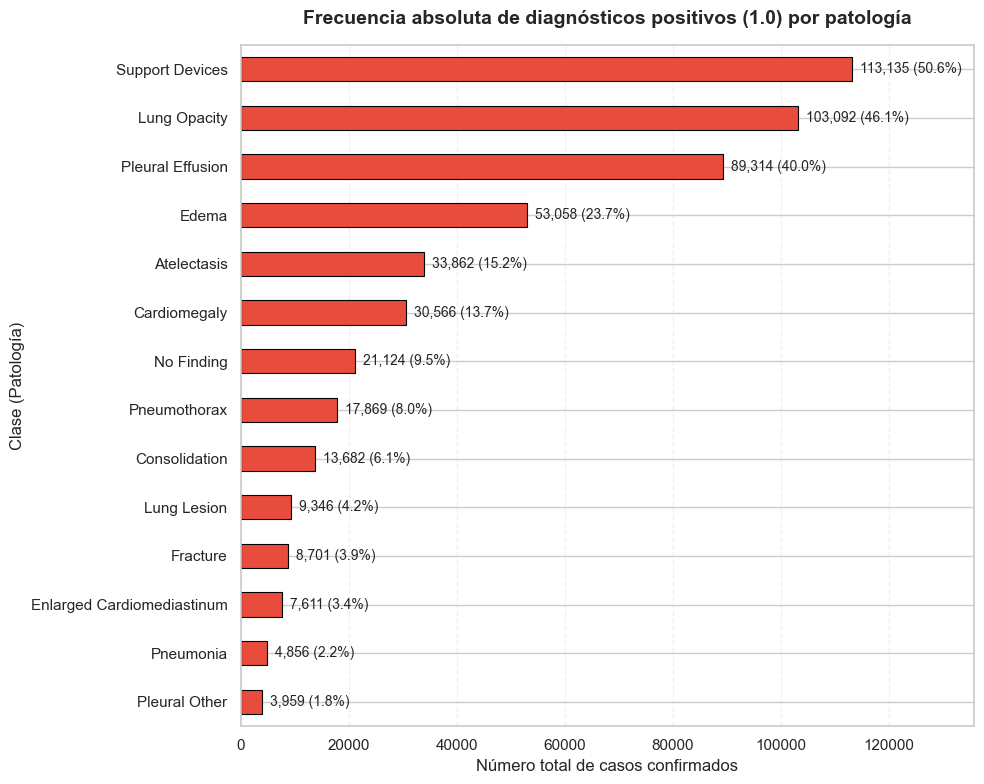

> **Interpretación visual:** El gráfico evidencia un desbalance severo (Long-tail). Clases como *Support Devices* o *Pleural Effusion* dominan la muestra, mientras que condiciones críticas como *Fracture* o *Pneumonia* presentan un grave déficit representacional.

In [11]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Extraer solo los positivos (1.0) para las 14 patologías
positivos_counts = (df_ini[cols_patologias] == 1.0).sum().sort_values(ascending=True)

# Obtener el total de observaciones del dataset para calcular los porcentajes
total_obs = len(df_ini)

fig, ax = plt.subplots(figsize=(10, 8))

# Crear gráfico de barras horizontales
positivos_counts.plot(kind='barh', color='#e74c3c', ax=ax, edgecolor='black', linewidth=0.8)

ax.set_title("Frecuencia absoluta de diagnósticos positivos (1.0) por patología", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Número total de casos confirmados", fontsize=12)
ax.set_ylabel("Clase (Patología)", fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Añadir el número exacto y el porcentaje al final de cada barra
for i, v in enumerate(positivos_counts):
    # Calcular porcentaje
    porcentaje = (v / total_obs) * 100
    # Formatear el texto (ejemplo: "113,135 (50.6%)")
    texto_etiqueta = f"{int(v):,} ({porcentaje:.1f}%)"
    
    # Colocar el texto un poco a la derecha del final de la barra
    ax.text(v + 1500, i, texto_etiqueta, va='center', fontsize=10)

# Expandir límite x para que quepa el texto (subimos de 1.15 a 1.20 porque el texto es más largo)
ax.set_xlim(0, positivos_counts.max() * 1.20)

plt.tight_layout()
plt.show()

display(Markdown("> **Interpretación visual:** El gráfico evidencia un desbalance severo (Long-tail). Clases como *Support Devices* o *Pleural Effusion* dominan la muestra, mientras que condiciones críticas como *Fracture* o *Pneumonia* presentan un grave déficit representacional."))

### 2.5.3. Frecuencia de diagnósticos inciertos (-1.0)

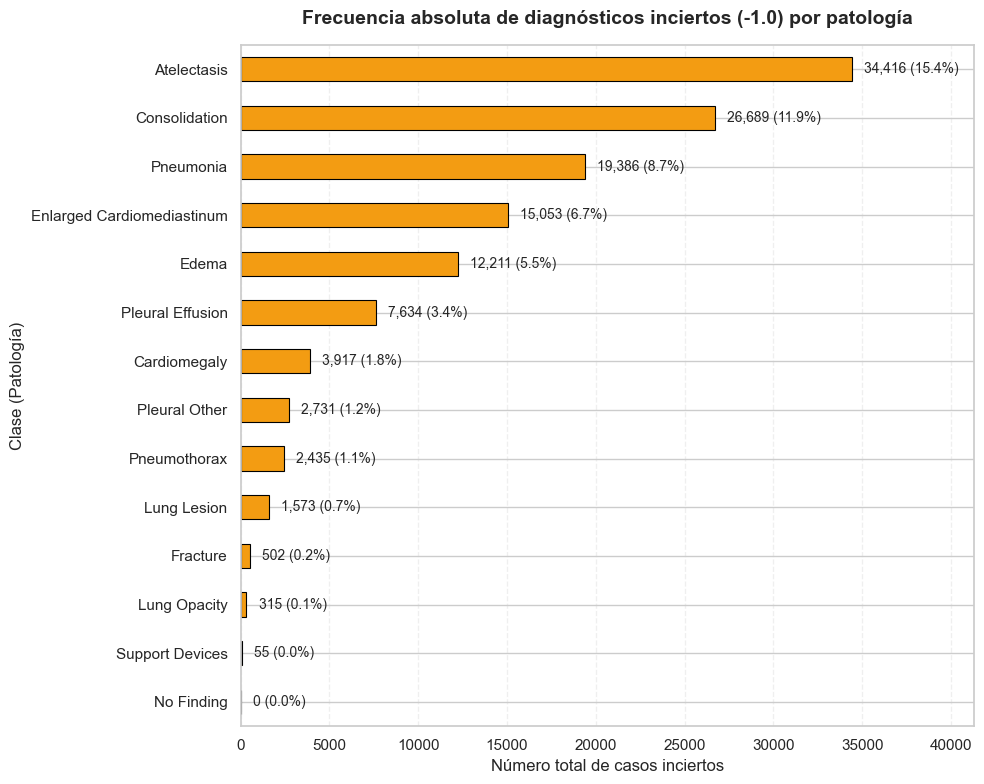

> **Interpretación visual:** Destaca la altísima incertidumbre en patologías pulmonares difusas como *Atelectasis* (15.4%) y *Consolidation* (11.9%). Estas condiciones son radiológicamente difíciles de distinguir sin el contexto clínico completo, lo que se refleja en la duda expresada por los radiólogos en los informes.

In [12]:
# Extraer solo los inciertos (-1.0)
inciertos_counts = (df_ini[cols_patologias] == -1.0).sum().sort_values(ascending=True)
total_obs = len(df_ini)

fig, ax = plt.subplots(figsize=(10, 8))

# Color naranja/amarillo (#f39c12) para representar advertencia/incertidumbre
inciertos_counts.plot(kind='barh', color='#f39c12', ax=ax, edgecolor='black', linewidth=0.8)

ax.set_title("Frecuencia absoluta de diagnósticos inciertos (-1.0) por patología", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Número total de casos inciertos", fontsize=12)
ax.set_ylabel("Clase (Patología)", fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Margen dinámico para el texto (2% del valor máximo)
margen_texto = inciertos_counts.max() * 0.02

# Añadir etiquetas de datos
for i, v in enumerate(inciertos_counts):
    porcentaje = (v / total_obs) * 100
    texto_etiqueta = f"{int(v):,} ({porcentaje:.1f}%)" if v > 0 else "0 (0.0%)"
    ax.text(v + margen_texto, i, texto_etiqueta, va='center', fontsize=10)

ax.set_xlim(0, inciertos_counts.max() * 1.20)
plt.tight_layout()
plt.show()

display(Markdown("> **Interpretación visual:** Destaca la altísima incertidumbre en patologías pulmonares difusas como *Atelectasis* (15.4%) y *Consolidation* (11.9%). Estas condiciones son radiológicamente difíciles de distinguir sin el contexto clínico completo, lo que se refleja en la duda expresada por los radiólogos en los informes."))

### 2.5.4. Frecuencia de patologías no mencionadas (NaN)

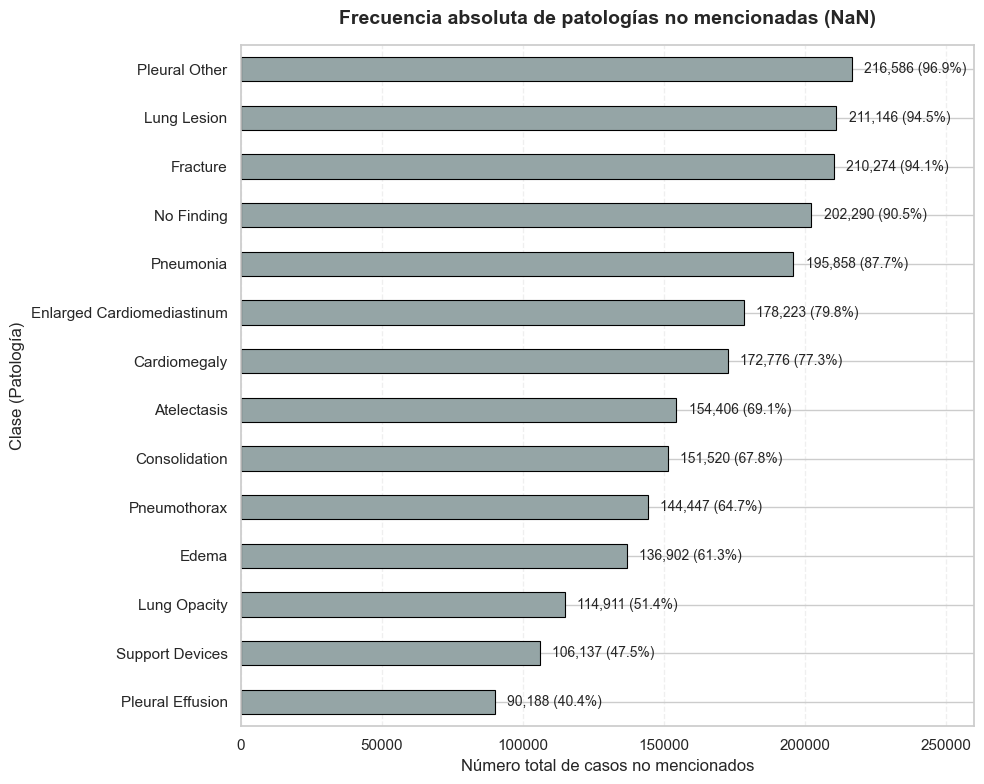

> **Interpretación visual:** La gráfica corrobora que la omisión es la norma en el dictado de informes radiológicos. Condiciones como *Fracture*, *Lung Lesion* o *Pleural Other* no se mencionan en más del 94% de los casos. Esto justifica la necesidad de utilizar estrategias como *U-Zeroes* (asumir que la no mención equivale a la ausencia de la patología) durante el entrenamiento del modelo.

In [13]:
# Extraer solo los valores nulos (NaN)
nan_counts = df_ini[cols_patologias].isna().sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Color gris (#95a5a6) para representar ausencia de mención
nan_counts.plot(kind='barh', color='#95a5a6', ax=ax, edgecolor='black', linewidth=0.8)

ax.set_title("Frecuencia absoluta de patologías no mencionadas (NaN)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Número total de casos no mencionados", fontsize=12)
ax.set_ylabel("Clase (Patología)", fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Margen dinámico para el texto (2% del valor máximo)
margen_texto = nan_counts.max() * 0.02

# Añadir etiquetas de datos
for i, v in enumerate(nan_counts):
    porcentaje = (v / total_obs) * 100
    texto_etiqueta = f"{int(v):,} ({porcentaje:.1f}%)"
    ax.text(v + margen_texto, i, texto_etiqueta, va='center', fontsize=10)

ax.set_xlim(0, nan_counts.max() * 1.20)
plt.tight_layout()
plt.show()

display(Markdown("> **Interpretación visual:** La gráfica corrobora que la omisión es la norma en el dictado de informes radiológicos. Condiciones como *Fracture*, *Lung Lesion* o *Pleural Other* no se mencionan en más del 94% de los casos. Esto justifica la necesidad de utilizar estrategias como *U-Zeroes* (asumir que la no mención equivale a la ausencia de la patología) durante el entrenamiento del modelo."))

### 2.5.5. Proporción de Diagnósticos Positivos vs. Inciertos

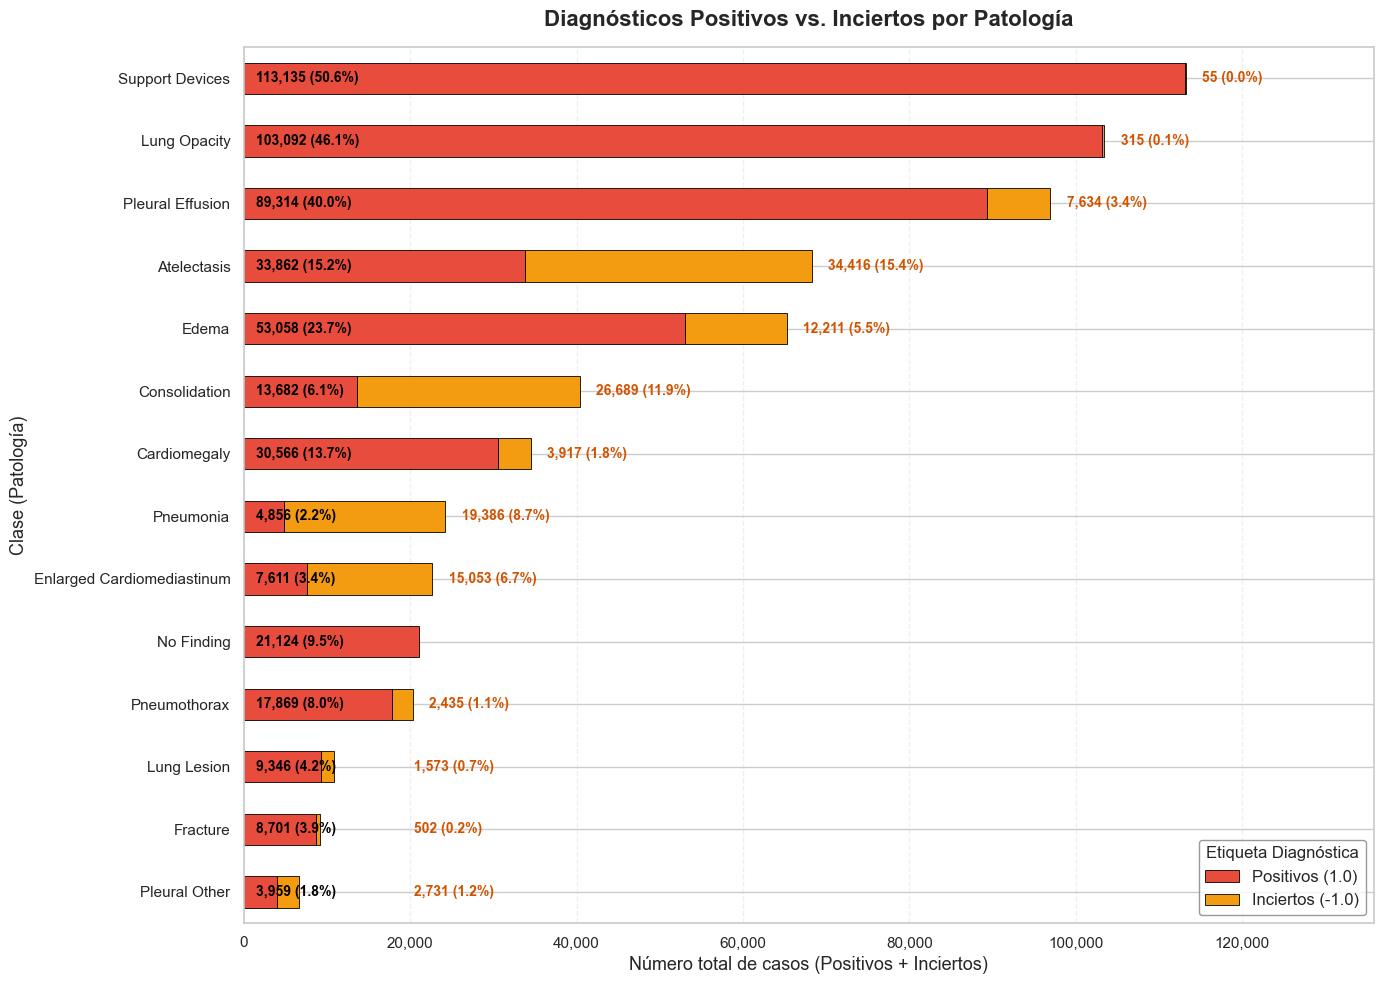

> **Interpretación visual:** Se han separado espacialmente las métricas para evitar solapamientos. Los números a la izquierda (dentro de la barra) representan los diagnósticos confirmados y su prevalencia global, mientras que los números a la derecha (fuera de la barra) cuantifican la incertidumbre diagnóstica. En patologías como *Atelectasis* el componente de incertidumbre (naranja) iguala o incluso supera al de confirmación (rojo).

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

# 1. Crear un DataFrame combinando los conteos de ambas clases
df_stack = pd.DataFrame({
    'Positivos (1.0)': (df_ini[cols_patologias] == 1.0).sum(),
    'Inciertos (-1.0)': (df_ini[cols_patologias] == -1.0).sum()
})

# 2. Calcular el total (Positivos + Inciertos) para ordenar el gráfico lógicamente
df_stack['Total_Activos'] = df_stack['Positivos (1.0)'] + df_stack['Inciertos (-1.0)']
df_stack = df_stack.sort_values(by='Total_Activos', ascending=True)

# 3. Configuración del lienzo
fig, ax = plt.subplots(figsize=(14, 10))
total_obs = len(df_ini) # Total del dataset para calcular los porcentajes

# 4. Crear el gráfico de barras horizontales apiladas
df_stack[['Positivos (1.0)', 'Inciertos (-1.0)']].plot(
    kind='barh', 
    stacked=True, 
    color=['#e74c3c', '#f39c12'], 
    ax=ax, 
    edgecolor='black', 
    linewidth=0.6
)

# 5. Añadir textos personalizados con valores absolutos y porcentajes
for i, (index, row) in enumerate(df_stack.iterrows()):
    val_pos = row['Positivos (1.0)']
    val_inc = row['Inciertos (-1.0)']
    total_barra = val_pos + val_inc
    
    # Texto para POSITIVOS (A la derecha de la marca del 0)
    if val_pos > 0:
        pct_pos = (val_pos / total_obs) * 100
        texto_pos = f"{int(val_pos):,} ({pct_pos:.1f}%)"
        ax.text(1500, i, texto_pos, va='center', ha='left', color='black', fontsize=10, fontweight='bold')
        
    # Texto para INCIERTOS (Regla anti-solapamiento)
    if val_inc > 0:
        pct_inc = (val_inc / total_obs) * 100
        texto_inc = f" {int(val_inc):,} ({pct_inc:.1f}%)"
        
        # --- SOLUCIÓN: Condición matemática de desplazamiento mínimo ---
        # Si la barra termina antes de 20000, el texto se pinta en la marca de 20000.
        # Si la barra es más larga, se pinta a +1500 del final de la barra.
        posicion_x_inciertos = max(total_barra + 1500, 20000)
        
        ax.text(posicion_x_inciertos, i, texto_inc, va='center', ha='left', color='#d35400', fontsize=10, fontweight='bold')

# 6. Formateo y estética
ax.set_title("Diagnósticos Positivos vs. Inciertos por Patología", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Número total de casos (Positivos + Inciertos)", fontsize=13)
ax.set_ylabel("Clase (Patología)", fontsize=13)

# Expandir el límite X un 20% para asegurar que el texto de los inciertos no se corte por la derecha
ax.set_xlim(0, df_stack['Total_Activos'].max() * 1.20)

# Formatear el eje X con separadores de miles
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Configurar leyenda
ax.legend(title="Etiqueta Diagnóstica", loc='lower right', frameon=True, facecolor='white', edgecolor='gray', fontsize=12)

plt.tight_layout()
plt.show()

# 7. Interpretación de los hallazgos
display(Markdown("> **Interpretación visual:** Se han separado espacialmente las métricas para evitar solapamientos. Los números a la izquierda (dentro de la barra) representan los diagnósticos confirmados y su prevalencia global, mientras que los números a la derecha (fuera de la barra) cuantifican la incertidumbre diagnóstica. En patologías como *Atelectasis* el componente de incertidumbre (naranja) iguala o incluso supera al de confirmación (rojo)."))

### 2.5.6. Mapa de calor de co-ocurrencia (Multimorbilidad)

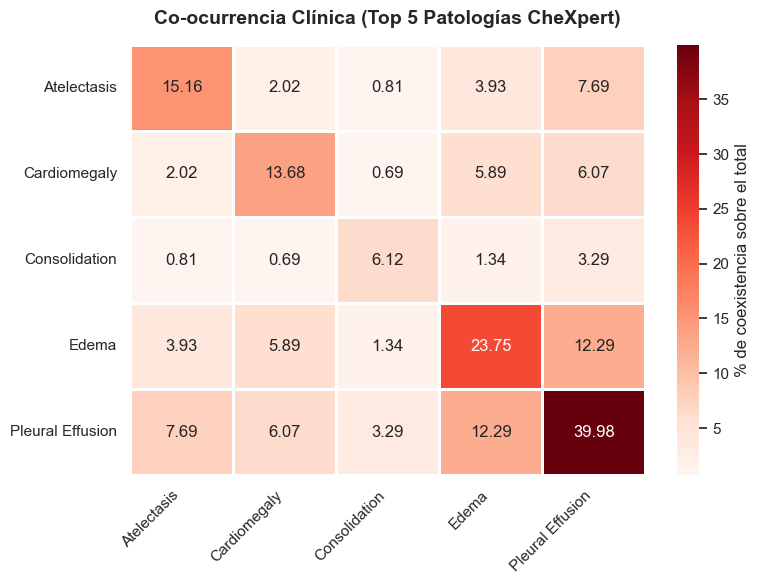

> **Interpretación visual:** La intensidad del color revela la alta dependencia multietiqueta del dataset. Destaca la coexistencia frecuente (celdas oscuras fuera de la diagonal) entre *Edema* y *Derrame Pleural (Pleural Effusion)*, lo que exigirá una función de pérdida independiente por clase (BCE) en lugar de funciones mutuamente excluyentes (Softmax).

In [15]:
# Seleccionar el Top-5 de patologías de la competición oficial
cols_top5 = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

# Calcular la matriz de porcentaje sobre el top 5
df_pos_top5 = (df_ini[cols_top5] == 1.0).astype(int)
matriz_cooc_abs_top5 = df_pos_top5.T.dot(df_pos_top5)
matriz_cooc_pct_top5 = (matriz_cooc_abs_top5 / len(df_ini)) * 100

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    matriz_cooc_pct_top5, 
    annot=True,            # Mostrar el número dentro de la celda
    fmt=".2f",             # Dos decimales
    cmap="Reds",           # Escala de colores
    cbar_kws={'label': '% de coexistencia sobre el total'},
    linewidths=1,
    linecolor='white',
    ax=ax
)

ax.set_title("Co-ocurrencia Clínica (Top 5 Patologías CheXpert)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(Markdown("> **Interpretación visual:** La intensidad del color revela la alta dependencia multietiqueta del dataset. Destaca la coexistencia frecuente (celdas oscuras fuera de la diagonal) entre *Edema* y *Derrame Pleural (Pleural Effusion)*, lo que exigirá una función de pérdida independiente por clase (BCE) en lugar de funciones mutuamente excluyentes (Softmax)."))

### 2.5.7. Mapa de calor de co-ocurrencia (Patologías > 10% de prevalencia)

**Patologías analizadas (Prevalencia > 10%):** Cardiomegaly, Lung Opacity, Edema, Atelectasis, Pleural Effusion, Support Devices

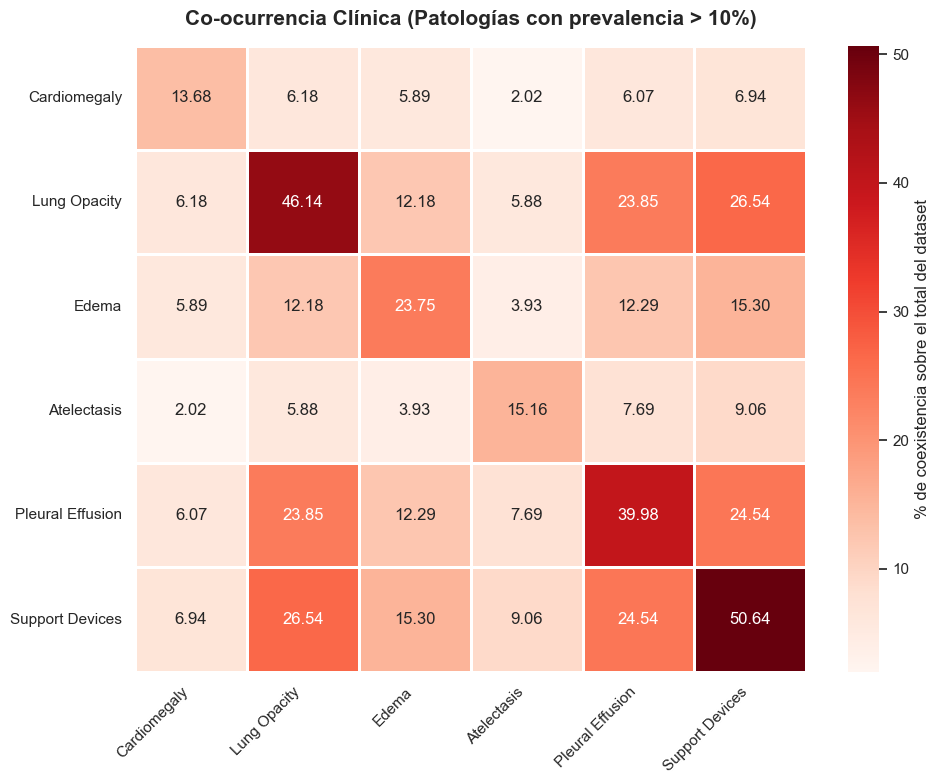

> **Interpretación visual:** Al filtrar por significancia estadística (>10%), el gráfico revela la fortísima correlación entre el tratamiento hospitalario y la sintomatología grave. La intensidad de los rojos destaca enormemente la celda que cruza *Lung Opacity* con *Support Devices* (26.54%), indicando que más de un cuarto de todos los pacientes del dataset tienen opacidades pulmonares y, simultáneamente, portan dispositivos médicos. Asimismo, la triada *Edema - Lung Opacity - Pleural Effusion* presenta una altísima dependencia multietiqueta.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. Filtrado dinámico: Encontrar patologías con más del 10% de casos positivos
prevalencia_positivos = (df_ini[cols_patologias] == 1.0).sum() / len(df_ini) * 100
cols_mayor_10 = prevalencia_positivos[prevalencia_positivos > 10.0].index.tolist()

display(Markdown(f"**Patologías analizadas (Prevalencia > 10%):** {', '.join(cols_mayor_10)}"))

# 2. Calcular la matriz de co-ocurrencia solo para estas columnas
df_pos_filtrado = (df_ini[cols_mayor_10] == 1.0).astype(int)
matriz_cooc_abs_filtrada = df_pos_filtrado.T.dot(df_pos_filtrado)
matriz_cooc_pct_filtrada = (matriz_cooc_abs_filtrada / len(df_ini)) * 100

# 3. Renderizado del Mapa de Calor (Cambiado a paleta roja)
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    matriz_cooc_pct_filtrada, 
    annot=True,            
    fmt=".2f",             
    cmap="Reds",          
    cbar_kws={'label': '% de coexistencia sobre el total del dataset'},
    linewidths=1,
    linecolor='white',
    ax=ax
)

ax.set_title("Co-ocurrencia Clínica (Patologías con prevalencia > 10%)", fontsize=15, fontweight='bold', pad=15)

# Rotar las etiquetas para legibilidad
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# 4. Interpretación
display(Markdown("> **Interpretación visual:** Al filtrar por significancia estadística (>10%), el gráfico revela la fortísima correlación entre el tratamiento hospitalario y la sintomatología grave. La intensidad de los rojos destaca enormemente la celda que cruza *Lung Opacity* con *Support Devices* (26.54%), indicando que más de un cuarto de todos los pacientes del dataset tienen opacidades pulmonares y, simultáneamente, portan dispositivos médicos. Asimismo, la triada *Edema - Lung Opacity - Pleural Effusion* presenta una altísima dependencia multietiqueta."))

### 2.5.8. Análisis Estructural: Pacientes vs. Radiografías (Riesgo de Data Leakage)


**Resumen Estructural de la Cohorte:**
* **Total de radiografías:** 223,414
* **Total de pacientes únicos:** 64,540
* **Media de radiografías por paciente:** 3.46
* **Máximo de radiografías para un solo paciente:** 92
* **Máximo de estudios clínicos para un solo paciente:** 91


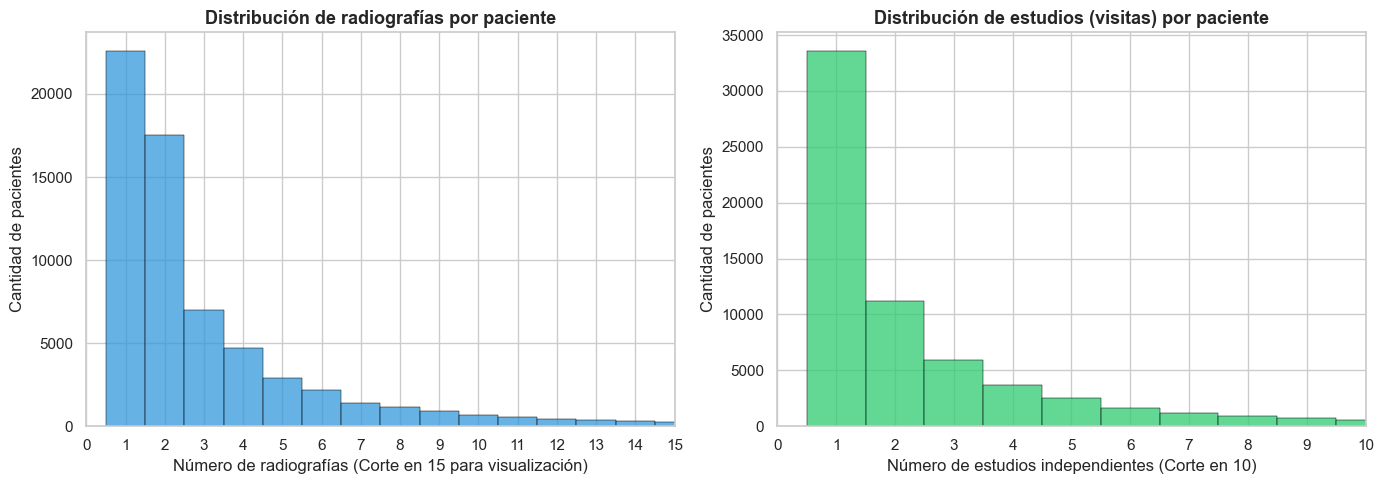

> **Interpretación visual y Alerta de *Data Leakage*:** Los gráficos y métricas demuestran que el dataset no tiene una relación 1:1 entre paciente e imagen. Existen pacientes crónicos con múltiples visitas al hospital (estudios) y decenas de radiografías acumuladas. Esto **prohíbe terminantemente realizar un *split* (división train/val/test) aleatorio simple** sobre las filas del CSV. Si la radiografía A de un paciente va al conjunto de entrenamiento y la radiografía B del mismo paciente va al conjunto de validación, la red neuronal memorizará la anatomía de esa persona en lugar de aprender a generalizar la patología (fuga de datos). La división del dataset deberá realizarse agrupando estrictamente por la nueva columna `Patient` generada.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. Extracción del ID del paciente y del estudio desde la ruta del archivo (Path)
# Utilizamos expresiones regulares (regex) para buscar los patrones 'patientXXXXX' y 'studyX'
df_ini['Patient'] = df_ini['Path'].str.extract(r'(patient\d+)')
df_ini['Study'] = df_ini['Path'].str.extract(r'(study\d+)')

# 2. Cálculos y estadísticas descriptivas
total_imagenes = len(df_ini)
total_pacientes = df_ini['Patient'].nunique()
ratio_imgs = total_imagenes / total_pacientes

imagenes_por_paciente = df_ini.groupby('Patient').size()
estudios_por_paciente = df_ini.groupby('Patient')['Study'].nunique()

display(Markdown(f"""
**Resumen Estructural de la Cohorte:**
* **Total de radiografías:** {total_imagenes:,}
* **Total de pacientes únicos:** {total_pacientes:,}
* **Media de radiografías por paciente:** {ratio_imgs:.2f}
* **Máximo de radiografías para un solo paciente:** {imagenes_por_paciente.max()}
* **Máximo de estudios clínicos para un solo paciente:** {estudios_por_paciente.max()}
"""))

# 3. Renderizado de la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Histograma 1: Imágenes por paciente
sns.histplot(imagenes_por_paciente, bins=range(1, 15), discrete=True, color='#3498db', ax=axes[0], edgecolor='black')
axes[0].set_title("Distribución de radiografías por paciente", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de radiografías (Corte en 15 para visualización)")
axes[0].set_ylabel("Cantidad de pacientes")
axes[0].set_xlim(0, 15)
axes[0].xaxis.set_major_locator(plt.MultipleLocator(1))

# Histograma 2: Estudios por paciente
sns.histplot(estudios_por_paciente, bins=range(1, 10), discrete=True, color='#2ecc71', ax=axes[1], edgecolor='black')
axes[1].set_title("Distribución de estudios (visitas) por paciente", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Número de estudios independientes (Corte en 10)")
axes[1].set_ylabel("Cantidad de pacientes")
axes[1].set_xlim(0, 10)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.show()

# 4. Interpretación metodológica crítica
display(Markdown("> **Interpretación visual y Alerta de *Data Leakage*:** Los gráficos y métricas demuestran que el dataset no tiene una relación 1:1 entre paciente e imagen. Existen pacientes crónicos con múltiples visitas al hospital (estudios) y decenas de radiografías acumuladas. Esto **prohíbe terminantemente realizar un *split* (división train/val/test) aleatorio simple** sobre las filas del CSV. Si la radiografía A de un paciente va al conjunto de entrenamiento y la radiografía B del mismo paciente va al conjunto de validación, la red neuronal memorizará la anatomía de esa persona en lugar de aprender a generalizar la patología (fuga de datos). La división del dataset deberá realizarse agrupando estrictamente por la nueva columna `Patient` generada."))

### 2.5.9. Distribución de estudios y radiografías por Sexo

**Resumen Estructural desglosado por Sexo:**

**Pacientes (Female):**
* Total de radiografías: 90,777
* Total de pacientes únicos: 28,728
* Media de radiografías por paciente: 3.16
* Máximo de radiografías para un solo paciente: 92
* Máximo de estudios clínicos para un solo paciente: 91

**Pacientes (Male):**
* Total de radiografías: 132,636
* Total de pacientes únicos: 35,811
* Media de radiografías por paciente: 3.70
* Máximo de radiografías para un solo paciente: 92
* Máximo de estudios clínicos para un solo paciente: 89

**Pacientes (Unknown):**
* Total de radiografías: 1
* Total de pacientes únicos: 1
* Media de radiografías por paciente: 1.00
* Máximo de radiografías para un solo paciente: 1
* Máximo de estudios clínicos para un solo paciente: 1



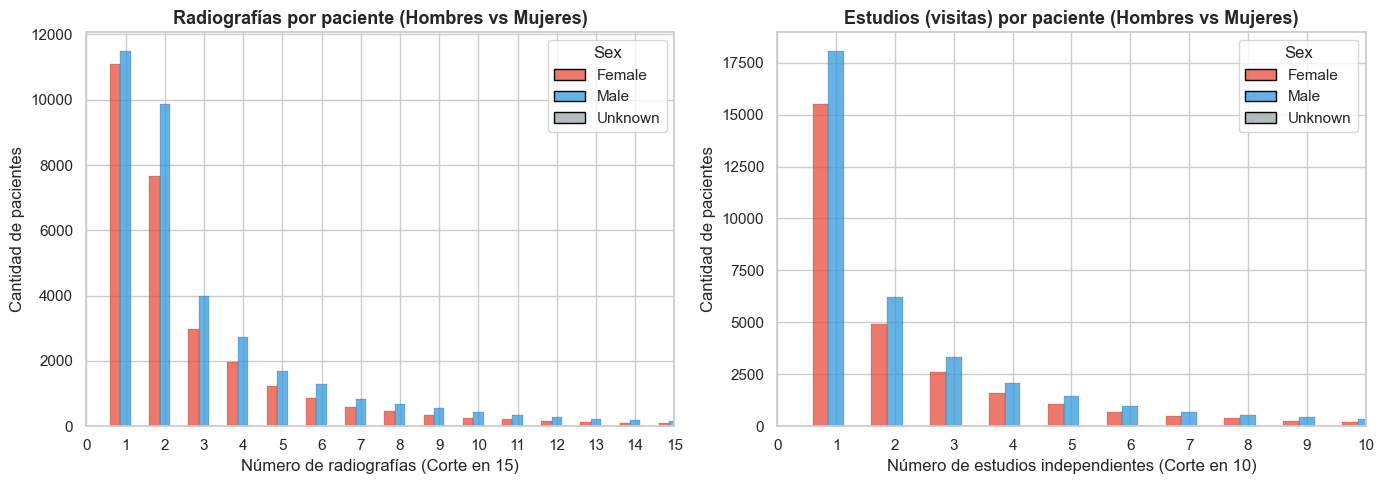

> **Interpretación visual:** Al segregar por sexo, podemos comparar de forma cuantitativa y visual si existe un sesgo demográfico en la cronicidad hospitalaria (si un grupo presenta sistemáticamente mayor volumen de readmisiones clínicas o seguimiento radiológico).

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. Agrupar a nivel de paciente, extrayendo el conteo de imágenes/estudios y su género
# Utilizamos 'first' asumiendo que el sexo del paciente no cambia entre sus distintas visitas
df_pacientes = df_ini.groupby('Patient').agg(
    Num_Radiografias=('Path', 'count'),
    Num_Estudios=('Study', 'nunique'),
    Sex=('Sex', 'first')
).reset_index()

# Limpiar posibles valores nulos en la columna de sexo (si los hay)
df_pacientes = df_pacientes.dropna(subset=['Sex'])

# 2. Generar el resumen de texto dinámico por cada sexo
texto_resumen = "**Resumen Estructural desglosado por Sexo:**\n\n"

# Iteramos sobre los sexos disponibles en el dataset
for sexo in df_pacientes['Sex'].unique():
    df_s = df_pacientes[df_pacientes['Sex'] == sexo]

    total_pacientes_s = len(df_s)
    total_radiografias_s = df_s['Num_Radiografias'].sum()
    media_radiografias_s = total_radiografias_s / total_pacientes_s
    max_radiografias_s = df_s['Num_Radiografias'].max()
    max_estudios_s = df_s['Num_Estudios'].max()

    texto_resumen += f"**Pacientes ({sexo}):**\n"
    texto_resumen += f"* Total de radiografías: {total_radiografias_s:,}\n"
    texto_resumen += f"* Total de pacientes únicos: {total_pacientes_s:,}\n"
    texto_resumen += f"* Media de radiografías por paciente: {media_radiografias_s:.2f}\n"
    texto_resumen += f"* Máximo de radiografías para un solo paciente: {max_radiografias_s}\n"
    texto_resumen += f"* Máximo de estudios clínicos para un solo paciente: {max_estudios_s}\n\n"

display(Markdown(texto_resumen))

# 3. Configuración del lienzo para los gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

radio_pa = 15  # Corte máximo para el eje X del histograma de radiografías
estudios_pa = 10  # Corte máximo para el eje X del histograma de estudios

# Paleta de colores consistente
colores_sexo = {'Male': '#3498db', 'Female': '#e74c3c', 'Unknown': '#95a5a6'}

# 4. Histograma 1: Imágenes por paciente agrupado por Sexo
sns.histplot(
    data=df_pacientes,
    x='Num_Radiografias',
    hue='Sex',
    multiple='dodge',  # Barras agrupadas lado a lado
    discrete=True,
    palette=colores_sexo,
    ax=axes[0],
    edgecolor='black',
    shrink=0.8
)

axes[0].set_title("Radiografías por paciente (Hombres vs Mujeres)", fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"Número de radiografías (Corte en {radio_pa})")
axes[0].set_ylabel("Cantidad de pacientes")
axes[0].set_xlim(0, radio_pa)
# axes[0].set_ylim(0, 100)
axes[0].xaxis.set_major_locator(plt.MultipleLocator(1))

# 5. Histograma 2: Estudios por paciente agrupado por Sexo
sns.histplot(
    data=df_pacientes,
    x='Num_Estudios',
    hue='Sex',
    multiple='dodge',
    discrete=True,
    palette=colores_sexo,
    ax=axes[1],
    edgecolor='black',
    shrink=0.8
)

axes[1].set_title("Estudios (visitas) por paciente (Hombres vs Mujeres)", fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"Número de estudios independientes (Corte en {estudios_pa})")
axes[1].set_ylabel("Cantidad de pacientes")
axes[1].set_xlim(0, estudios_pa)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.show()

display(Markdown("> **Interpretación visual:** Al segregar por sexo, podemos comparar de forma cuantitativa y visual si existe un sesgo demográfico en la cronicidad hospitalaria (si un grupo presenta sistemáticamente mayor volumen de readmisiones clínicas o seguimiento radiológico)."))

# 3. Extracción de muestras

## 3.1 Extracción de muestras con "Suppor Devices"

In [19]:
import os
import shutil
import re
import pandas as pd
from IPython.display import display, Markdown

# =====================================================================
# 1. PANEL DE BÚSQUEDA (Rellene lo que quiera encontrar)
# =====================================================================
directorio_raiz = r"C:\CheXpertDataset\chexpertchestxrays-u20210408"

# 1. Patologías que DEBEN estar presentes (1.0). Deje la lista [] si le da igual.
patologias_requeridas = ['Support Devices']

# 2. Vista requerida ('Frontal', 'Lateral' o deje None si le da igual)
vista_requerida = 'Frontal'

# 3. Posición requerida ('AP', 'PA', 'LL' o deje None si le da igual)
posicion_requerida = 'AP'

# 4. Sexo del paciente ('Male', 'Female' o deje None si le da igual)
sexo_requerido = None

# Configuración de salida
numero_imagenes_a_extraer = 50
carpeta_destino = r"muestras_busqueda"

posibles_batches = [
    "CheXpert-v1.0 batch 2 (train 1)",
    "CheXpert-v1.0 batch 3 (train 2)",
    "CheXpert-v1.0 batch 4 (train 3)"
]

os.makedirs(carpeta_destino, exist_ok=True)

# =====================================================================
# 2. MOTOR DE BÚSQUEDA
# =====================================================================
df_busqueda = df_ini.copy()

# A. Filtrar por Patologías
for patologia in patologias_requeridas:
    df_busqueda = df_busqueda[df_busqueda[patologia] == 1.0]

# B. Filtrar por Vista
if vista_requerida is not None:
    df_busqueda = df_busqueda[df_busqueda['Frontal/Lateral'] == vista_requerida]

# C. Filtrar por Posición
if posicion_requerida is not None:
    df_busqueda = df_busqueda[df_busqueda['AP/PA'] == posicion_requerida]

# D. Filtrar por Sexo
if sexo_requerido is not None:
    col_sexo = 'Sex' if 'Sex' in df_busqueda.columns else 'GENDER'
    df_busqueda = df_busqueda[df_busqueda[col_sexo] == sexo_requerido]

# =====================================================================
# 3. EXTRACCIÓN Y COPIA
# =====================================================================
total_disponibles = len(df_busqueda)
n_extraer = min(numero_imagenes_a_extraer, total_disponibles)

imagenes_copiadas = 0
imagenes_no_encontradas = 0

if n_extraer > 0:
    # Seleccionamos al azar de las que cumplen TODAS las condiciones
    df_muestra = df_busqueda.sample(n=n_extraer, random_state=42)

    for index, row in df_muestra.iterrows():
        ruta_csv = row['Path']
        match = re.search(r'(patient\d+/study\d+/.*\.jpg)', ruta_csv)
        
        if match:
            parte_relativa = match.group(1).replace('/', os.sep)
            archivo_encontrado = False
            
            for batch in posibles_batches:
                ruta_origen = os.path.join(directorio_raiz, batch, parte_relativa)
                if os.path.exists(ruta_origen):
                    # Guardamos la imagen con un nombre descriptivo
                    nombre_archivo = f"{row['Patient']}_{parte_relativa.split(os.sep)[-1]}"
                    ruta_destino = os.path.join(carpeta_destino, nombre_archivo)
                    
                    shutil.copy2(ruta_origen, ruta_destino)
                    imagenes_copiadas += 1
                    archivo_encontrado = True
                    break 
            
            if not archivo_encontrado:
                imagenes_no_encontradas += 1
        else:
            imagenes_no_encontradas += 1

# =====================================================================
# 4. REPORTE FINAL
# =====================================================================
display(Markdown(f"""
**🔍 Resultados de la Búsqueda:**
* **Criterios:** Patologías: `{patologias_requeridas}`, Vista: `{vista_requerida}`, Posición: `{posicion_requerida}`, Sexo: `{sexo_requerido}`
* **Imágenes que cumplen sus criterios en el dataset:** {total_disponibles:,}
* **Copiadas con éxito a `{carpeta_destino}`:** {imagenes_copiadas}
* **No encontradas en el disco duro:** {imagenes_no_encontradas}
"""))


**🔍 Resultados de la Búsqueda:**
* **Criterios:** Patologías: `['Support Devices']`, Vista: `Frontal`, Posición: `AP`, Sexo: `None`
* **Imágenes que cumplen sus criterios en el dataset:** 97,988
* **Copiadas con éxito a `muestras_busqueda`:** 50
* **No encontradas en el disco duro:** 0


## 3.2 Impacto de exclusión de muestras por patología

In [20]:
import pandas as pd
from IPython.display import display, Markdown

# 1. Definir las etiquetas que queremos evaluar para exclusión
# Puede modificar esta lista con cualquier patología que desee analizar
# etiquetas_a_excluir = [
#     'No Finding', 
#     'Enlarged Cardiomediastinum', 
#     'Cardiomegaly', 
#     'Lung Opacity', 
#     'Lung Lesion', 
#     'Edema', 
#     'Consolidation', 
#     'Pneumonia', 
#     'Atelectasis', 
#     'Pneumothorax', 
#     'Pleural Effusion', 
#     'Pleural Other', 
#     'Fracture', 
#     'Support Devices'
# ]

etiquetas_a_excluir = [
    'Pleural Other', 
]
# 2. Calcular el tamaño original
total_original = len(df_ini)

# 3. Identificar las filas que tienen un positivo (1.0) en ALGUNA de las etiquetas a excluir
# Creamos una máscara booleana que será True si alguna de las columnas especificadas es igual a 1.0
mascara_exclusion = (df_ini[etiquetas_a_excluir] == 1.0).any(axis=1)

# 4. Calcular los conjuntos resultantes
df_excluido = df_ini[mascara_exclusion]
df_restante = df_ini[~mascara_exclusion]

total_excluido = len(df_excluido)
total_restante = len(df_restante)

porcentaje_perdida = (total_excluido / total_original) * 100
porcentaje_retencion = (total_restante / total_original) * 100

# 5. Mostrar los resultados
display(Markdown(f"""
**Análisis de reducción del Dataset:**
Al plantear la eliminación de todas las radiografías que sean positivas en: `{', '.join(etiquetas_a_excluir)}`

* **Tamaño original del dataset:** {total_original:,} imágenes.
* **Imágenes que serían eliminadas:** {total_excluido:,} ({porcentaje_perdida:.2f}% del total).
* **Imágenes que quedarían útiles:** {total_restante:,} ({porcentaje_retencion:.2f}% del total).
"""))


**Análisis de reducción del Dataset:**
Al plantear la eliminación de todas las radiografías que sean positivas en: `Pleural Other`

* **Tamaño original del dataset:** 223,414 imágenes.
* **Imágenes que serían eliminadas:** 3,959 (1.77% del total).
* **Imágenes que quedarían útiles:** 219,455 (98.23% del total).


## 3.3 Impacto de exclusión de muestras con incertidumbre (-1.0)

In [21]:
import pandas as pd
from IPython.display import display, Markdown

# 1. Definir las 14 columnas de patologías
cols_patologias = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
]

# 2. Calcular el tamaño original del dataset
total_original = len(df_ini)

# 3. Identificar las filas que tienen un -1.0 en ALGUNA de las patologías
# Utilizamos any(axis=1) para buscar por filas
mascara_incertidumbre = (df_ini[cols_patologias] == -1.0).any(axis=1)

# 4. Calcular los conjuntos resultantes
df_sin_incertidumbre = df_ini[~mascara_incertidumbre] # El símbolo ~ invierte la máscara (los que NO tienen -1.0)
df_con_incertidumbre = df_ini[mascara_incertidumbre]

total_excluido = len(df_con_incertidumbre)
total_restante = len(df_sin_incertidumbre)

porcentaje_perdida = (total_excluido / total_original) * 100
porcentaje_retencion = (total_restante / total_original) * 100

# 5. Mostrar los resultados de la simulación
display(Markdown(f"""
**Análisis de reducción por Incertidumbre (Política U-Ignore):**
Al plantear la eliminación de todas las radiografías que presenten al menos un diagnóstico incierto (`-1.0`) en cualquiera de las 14 etiquetas:

* **Tamaño original del dataset:** {total_original:,} imágenes.
* **Imágenes que serían eliminadas:** {total_excluido:,} ({porcentaje_perdida:.2f}% del total).
* **Imágenes que quedarían útiles:** {total_restante:,} ({porcentaje_retencion:.2f}% del total).
"""))


**Análisis de reducción por Incertidumbre (Política U-Ignore):**
Al plantear la eliminación de todas las radiografías que presenten al menos un diagnóstico incierto (`-1.0`) en cualquiera de las 14 etiquetas:

* **Tamaño original del dataset:** 223,414 imágenes.
* **Imágenes que serían eliminadas:** 80,011 (35.81% del total).
* **Imágenes que quedarían útiles:** 143,403 (64.19% del total).


# 4 Simulador Global de Exclusión de Muestras (Pipeline de Filtrado)

In [22]:
from Funciones.filtrar_chexpert_dataset import filtrar_chexpert_dataset

# =====================================================================
# 1. PANEL DE CONFIGURACIÓN (Modifique estas listas según su criterio)
# =====================================================================

excluir_positivos_en = ['Pleural Other']
excluir_vistas = ['Lateral']
excluir_posiciones = ['PA']
excluir_valores_globales = [-1.0]
eliminar_inconsistencias_nofinding = True

# Filtros adicionales opcionales
filtrar_edad_min = None
filtrar_edad_max = None
filtrar_sexo = None  # ej. ["Male", "Female"]

# =====================================================================
# 2. FILTRADO UTILIZANDO LA FUNCIÓN
# =====================================================================

df_filtrado, reporte = filtrar_chexpert_dataset(
    df_ini=df_ini,
    excluir_positivos_en=excluir_positivos_en,
    excluir_vistas=excluir_vistas,
    excluir_posiciones=excluir_posiciones,
    excluir_valores_globales=excluir_valores_globales,
    excluir_incertidumbre=True,  # eliminar filas con -1.0
    eliminar_inconsistencias_nofinding=eliminar_inconsistencias_nofinding,
    filtrar_edad_min=filtrar_edad_min,
    filtrar_edad_max=filtrar_edad_max,
    filtrar_sexo=filtrar_sexo
)

# =====================================================================
# 3. REPORTE DE RESULTADOS
# =====================================================================

display(Markdown(f"""
**Reporte del Pipeline de Exclusión:**  

* **Dataset Inicial:** {reporte['total_original']:,} imágenes.  
* **Dataset Final Útil:** **{reporte['total_final']:,}** imágenes ({reporte['porcentaje_retencion']:.2f}% retenido).  
* **Imágenes Eliminadas:** {reporte['total_perdido']:,} ({reporte['porcentaje_perdido']:.2f}% perdido).  

**Desglose de la eliminación en cascada:**  
1. Eliminadas por ser positivas en `{excluir_positivos_en}`: **{reporte['perdida_por_positivos']:,}**  
2. Eliminadas por ser vista `{excluir_vistas}`: **{reporte['perdida_por_vista']:,}**  
3. Eliminadas por ser posición `{excluir_posiciones}`: **{reporte['perdida_por_posicion']:,}**  
4. Eliminadas por contener los valores `{excluir_valores_globales}` o incertidumbre: **{reporte['perdida_por_valores']:,}**  
5. Eliminadas por inconsistencia (`No Finding=1.0` y al menos otra patología positiva): **{reporte['perdida_por_inconsistencia']:,}**  
6. Eliminadas por edad fuera de rango: **{reporte['perdida_por_edad']:,}**  
7. Eliminadas por sexo excluido: **{reporte['perdida_por_sexo']:,}**
"""))


**Reporte del Pipeline de Exclusión:**  

* **Dataset Inicial:** 223,414 imágenes.  
* **Dataset Final Útil:** **95,556** imágenes (42.77% retenido).  
* **Imágenes Eliminadas:** 127,858 (57.23% perdido).  

**Desglose de la eliminación en cascada:**  
1. Eliminadas por ser positivas en `['Pleural Other']`: **3,959**  
2. Eliminadas por ser vista `['Lateral']`: **31,232**  
3. Eliminadas por ser posición `['PA']`: **28,271**  
4. Eliminadas por contener los valores `[-1.0]` o incertidumbre: **58,973**  
5. Eliminadas por inconsistencia (`No Finding=1.0` y al menos otra patología positiva): **5,423**  
6. Eliminadas por edad fuera de rango: **0**  
7. Eliminadas por sexo excluido: **0**


### 4.1 Distribución de Patologías (Dataset Filtrado)

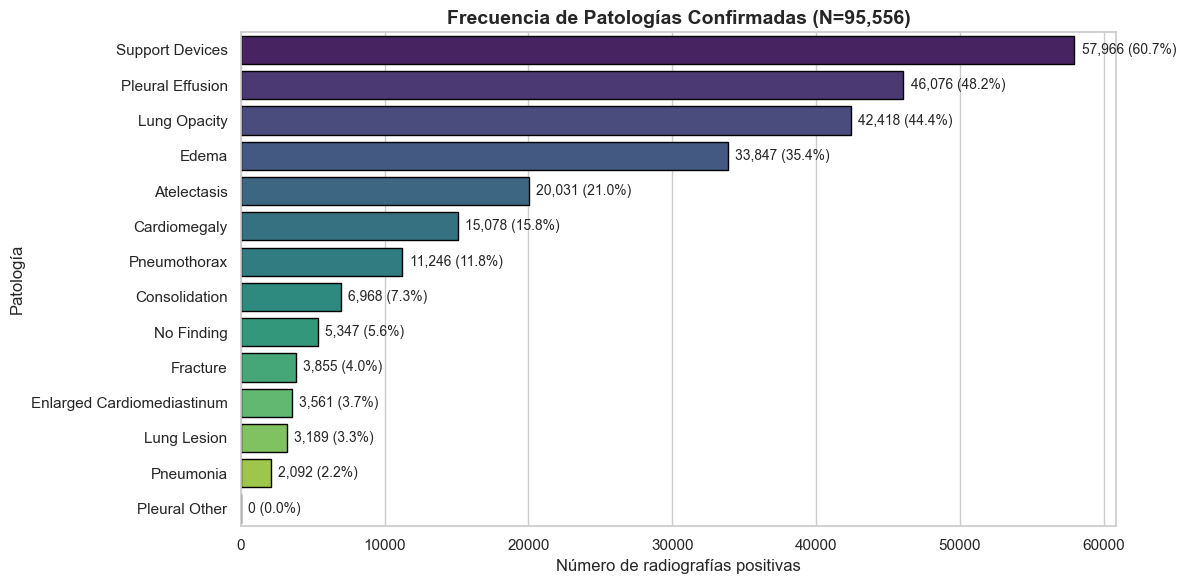

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, Markdown

cols_patologias = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
]

# Calculamos cuántos '1.0' puros quedan en cada patología
conteo_positivos = (df_filtrado[cols_patologias] == 1.0).sum().sort_values(ascending=False)
porcentajes = (conteo_positivos / len(df_filtrado)) * 100

fig, ax = plt.subplots(figsize=(12, 6))

# --- CÓDIGO CORREGIDO PARA SEABORN ---
sns.barplot(
    x=conteo_positivos.values, 
    y=conteo_positivos.index, 
    hue=conteo_positivos.index,   # Asignamos hue al eje Y para silenciar el aviso
    palette='viridis', 
    legend=False,                 # Ocultamos la leyenda automática
    ax=ax, 
    edgecolor='black'
)
# -------------------------------------

# Añadir etiquetas de datos
for i, (valor, pct) in enumerate(zip(conteo_positivos.values, porcentajes.values)):
    ax.text(valor + 500, i, f"{valor:,} ({pct:.1f}%)", va='center', fontsize=10)

ax.set_title(f"Frecuencia de Patologías Confirmadas (N={len(df_filtrado):,})", fontsize=14, fontweight='bold')
ax.set_xlabel("Número de radiografías positivas")
ax.set_ylabel("Patología")
plt.tight_layout()
plt.show()

### 4.2 Co-ocurrencia Clínica (Dataset Filtrado)

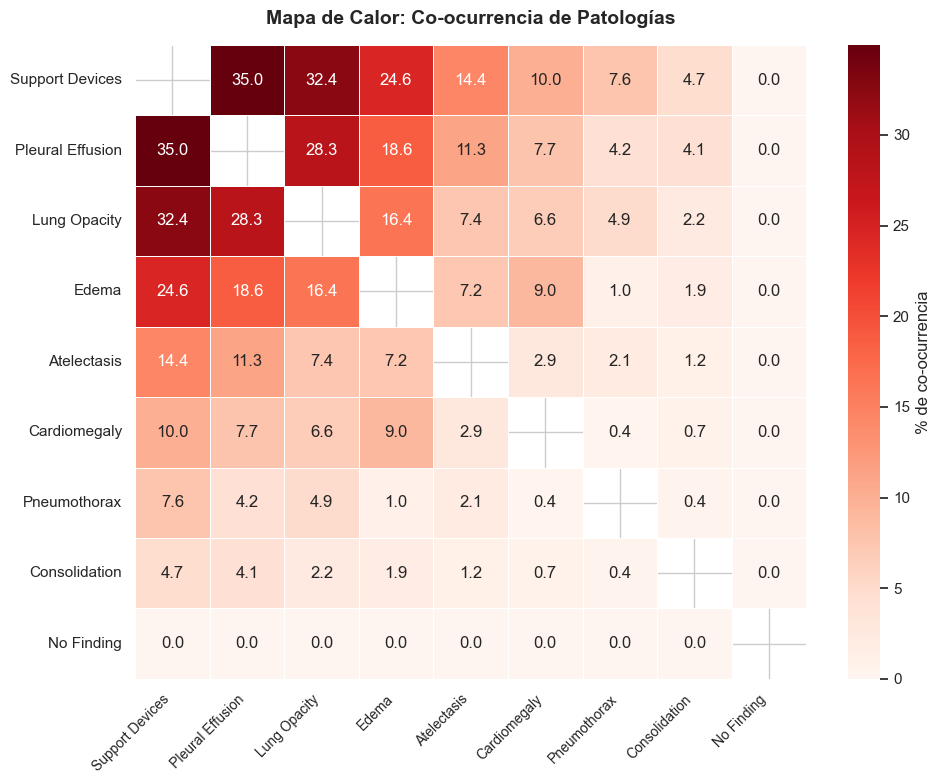

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, Markdown

# Nos quedamos solo con las filas que tienen al menos un 1.0 y convertimos todo a binario estricto (1 o 0)
df_binario = (df_filtrado[cols_patologias] == 1.0).astype(int)

# Calculamos la matriz de co-ocurrencia (producto punto)
matriz_coocurrencia = df_binario.T.dot(df_binario)

# Normalizamos por el total de imágenes en el dataset filtrado
matriz_coocurrencia_pct = (matriz_coocurrencia / len(df_filtrado)) * 100

# Filtramos patologías con baja prevalencia para limpiar el gráfico (ej. > 5%)
patologias_frecuentes = porcentajes[porcentajes > 5.0].index

# 1. SOLUCIÓN: Añadimos .copy() para crear un DataFrame de escritura
matriz_filtrada = matriz_coocurrencia_pct.loc[patologias_frecuentes, patologias_frecuentes].copy()

# 2. SOLUCIÓN: Vaciamos la diagonal de forma segura y nativa en Pandas
for patologia in matriz_filtrada.columns:
    matriz_filtrada.loc[patologia, patologia] = np.nan

# Dibujamos el mapa de calor
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    matriz_filtrada, 
    annot=True, 
    fmt=".1f", 
    cmap="Reds", 
    cbar_kws={'label': '% de co-ocurrencia'},
    linewidths=0.5,
    ax=ax
)

ax.set_title("Mapa de Calor: Co-ocurrencia de Patologías", fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

### 4.3 Estructura de Pacientes y Sexo (Dataset Filtrado)

**Resumen Estructural del Dataset Filtrado:**

**Pacientes (Male):**
* Total de radiografías: 55,338
* Total de pacientes únicos: 21,284
* Media de radiografías por paciente: 2.60

**Pacientes (Female):**
* Total de radiografías: 40,218
* Total de pacientes únicos: 17,435
* Media de radiografías por paciente: 2.31



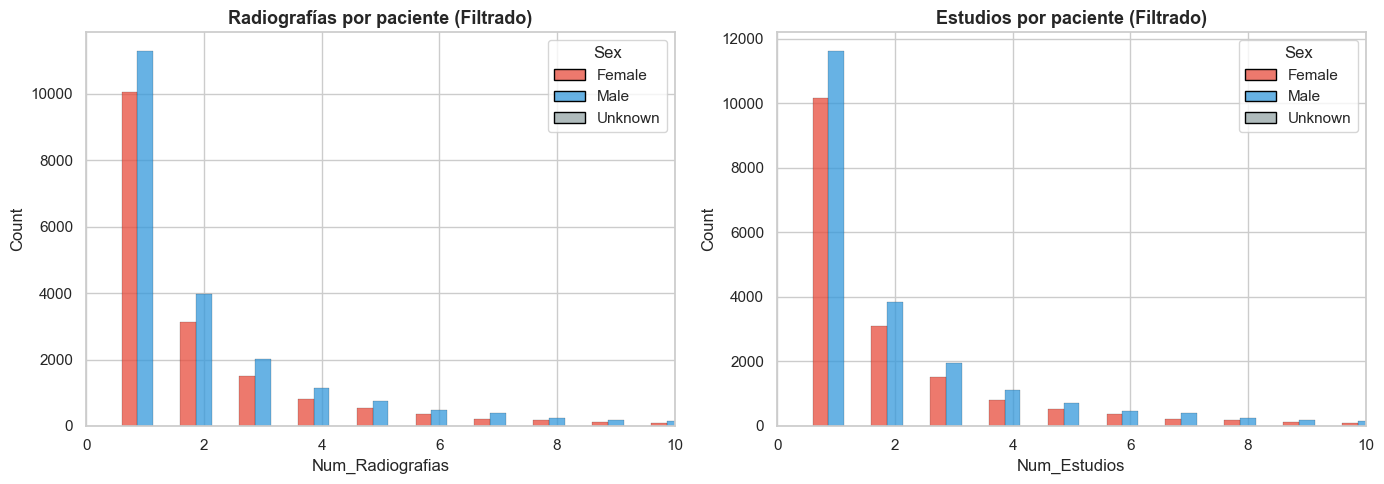

> **Interpretación metodológica:** Si las gráficas estructurales o de prevalencia muestran un desbalance extremo (por ejemplo, si *Pneumonia* ha bajado a solo 500 imágenes), sabremos que el nivel de filtrado aplicado fue demasiado severo y deberemos relajar las restricciones en el Simulador Global.

In [25]:
# Agrupamos los datos restantes por paciente
df_pacientes_filt = df_filtrado.groupby('Patient').agg(
    Num_Radiografias=('Path', 'count'),
    Num_Estudios=('Study', 'nunique'),
    Sex=('Sex', 'first')
).reset_index()

df_pacientes_filt = df_pacientes_filt.dropna(subset=['Sex'])

# Resumen numérico
texto_resumen = "**Resumen Estructural del Dataset Filtrado:**\n\n"
for sexo in df_pacientes_filt['Sex'].unique():
    df_s = df_pacientes_filt[df_pacientes_filt['Sex'] == sexo]
    texto_resumen += f"**Pacientes ({sexo}):**\n"
    texto_resumen += f"* Total de radiografías: {df_s['Num_Radiografias'].sum():,}\n"
    texto_resumen += f"* Total de pacientes únicos: {len(df_s):,}\n"
    texto_resumen += f"* Media de radiografías por paciente: {df_s['Num_Radiografias'].mean():.2f}\n\n"

display(Markdown(texto_resumen))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")
colores_sexo = {'Male': '#3498db', 'Female': '#e74c3c', 'Unknown': '#95a5a6'}

sns.histplot(data=df_pacientes_filt, x='Num_Radiografias', hue='Sex', multiple='dodge', discrete=True, palette=colores_sexo, ax=axes[0], edgecolor='black', shrink=0.8)
axes[0].set_title("Radiografías por paciente (Filtrado)", fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 10)

sns.histplot(data=df_pacientes_filt, x='Num_Estudios', hue='Sex', multiple='dodge', discrete=True, palette=colores_sexo, ax=axes[1], edgecolor='black', shrink=0.8)
axes[1].set_title("Estudios por paciente (Filtrado)", fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

display(Markdown("> **Interpretación metodológica:** Si las gráficas estructurales o de prevalencia muestran un desbalance extremo (por ejemplo, si *Pneumonia* ha bajado a solo 500 imágenes), sabremos que el nivel de filtrado aplicado fue demasiado severo y deberemos relajar las restricciones en el Simulador Global."))

### 4.4 Análisis Demográfico: Distribución de Edad y Patologías

C:\Users\migue\AppData\Local\Temp\ipykernel_21116\3234371434.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha='right')


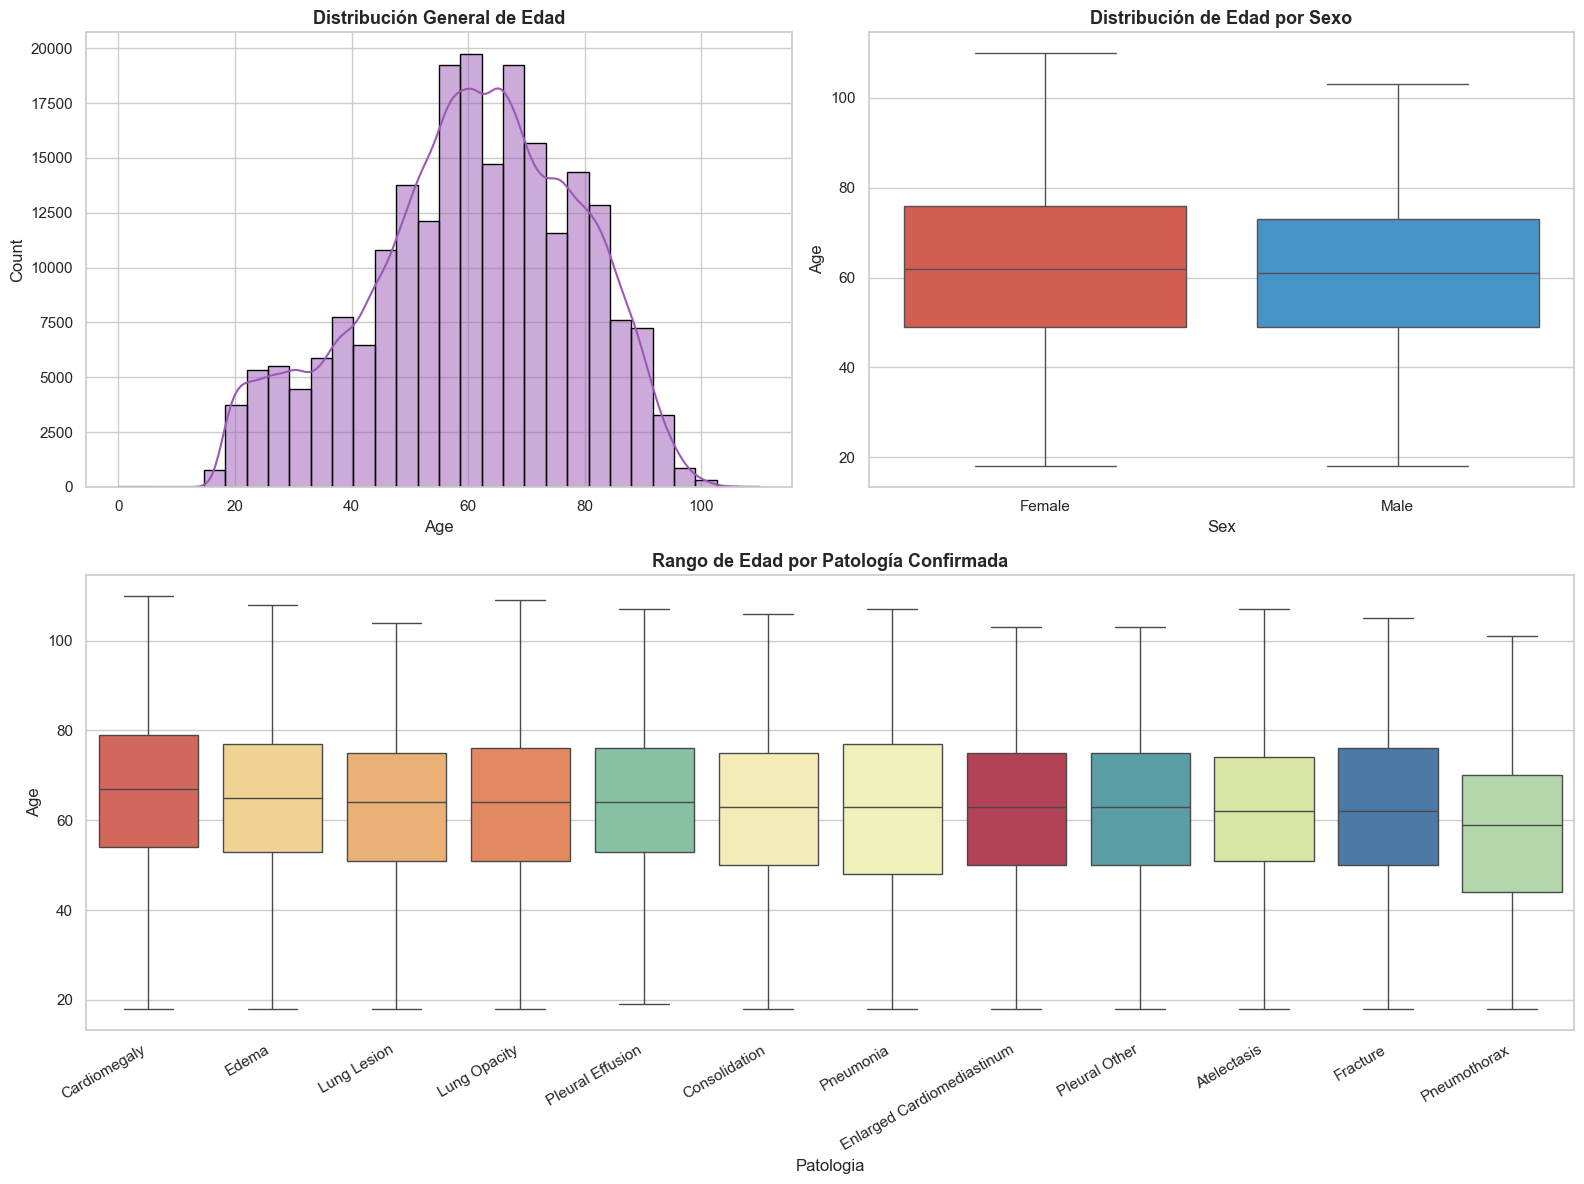

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

# 1. Asegurar nombres de columnas
col_edad = 'Age' if 'Age' in df_ini.columns else 'AGE_AT_CXR'
col_sexo = 'Sex' if 'Sex' in df_ini.columns else 'GENDER'

# Filtrar edades válidas
df_edad = df_ini[(df_ini[col_edad] >= 0) & (df_ini[col_edad] <= 110)].copy()

fig = plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

# --- GRÁFICO 1: Distribución General ---
ax1 = plt.subplot(2, 2, 1)
sns.histplot(data=df_edad, x=col_edad, bins=30, kde=True, color='#9b59b6', ax=ax1, edgecolor='black')
ax1.set_title("Distribución General de Edad", fontsize=13, fontweight='bold')

# --- GRÁFICO 2: Edad por Sexo (Cambiado a Boxplot clásico) ---
ax2 = plt.subplot(2, 2, 2)

# Filtramos y nos aseguramos de que no queden categorías fantasma de 'Unknown'
df_sexo_valido = df_edad[df_edad[col_sexo].isin(['Male', 'Female'])].copy()
if hasattr(df_sexo_valido[col_sexo], 'cat'):
    df_sexo_valido[col_sexo] = df_sexo_valido[col_sexo].cat.remove_unused_categories()

# Usamos boxplot clásico
sns.boxplot(
    data=df_sexo_valido, 
    x=col_sexo, 
    y=col_edad, 
    hue=col_sexo,             # Asignamos hue para que coincida con la paleta
    palette={'Male': '#3498db', 'Female': '#e74c3c'}, 
    legend=False,             # Quitamos la leyenda sobrante
    ax=ax2,
    showfliers=False          # Opcional: oculta los puntos atípicos para mayor limpieza
)
ax2.set_title("Distribución de Edad por Sexo", fontsize=13, fontweight='bold')

# --- GRÁFICO 3: Boxplots por Patología ---
ax3 = plt.subplot(2, 1, 2)

cols_patologias = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture'
]

lista_edades_patologias = []
for patologia in cols_patologias:
    # Verificamos si la patología existe en las columnas para evitar errores
    if patologia in df_edad.columns:
        edades = df_edad[df_edad[patologia] == 1.0][col_edad]
        temp_df = pd.DataFrame({col_edad: edades, 'Patologia': patologia})
        lista_edades_patologias.append(temp_df)

if lista_edades_patologias:
    df_melted = pd.concat(lista_edades_patologias)
    orden_patologias = df_melted.groupby('Patologia')[col_edad].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df_melted, 
        x='Patologia', 
        y=col_edad, 
        order=orden_patologias,
        hue='Patologia',      # Añadido para evitar avisos de Seaborn
        palette='Spectral', 
        legend=False,
        ax=ax3,
        showfliers=False 
    )
    ax3.set_title("Rango de Edad por Patología Confirmada", fontsize=13, fontweight='bold')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()